# Planning-Action Disconnect in Large Language Models


Planning Action Disconnect in Large Language Models:
A Causal Analysis of Action Commitment and Suppression

Research Hypotheses:
  H1: Planning and action are mechanistically separable representations in LLMs
  H2: Action execution depends on a distinct "Action Commitment Signal" (ACS)
  H3: Failures occur due to (a) insufficient activation or (b) downstream suppression
  H4: Execution failure is predictable from intermediate activations before output



## 1: ENVIRONMENT SETUP


In [1]:
# SECTION 1: ENVIRONMENT SETUP

import subprocess, sys

def pip_install(packages):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + packages,
        capture_output=True
    )

pip_install(["transformers==4.40.0", "torch", "scikit-learn",
             "matplotlib", "seaborn", "tqdm", "numpy", "scipy"])

import os, re, gc, json, copy, random, warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any
from tqdm import tqdm

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, roc_curve,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy.spatial.distance import cosine as cosine_dist
from scipy.linalg import subspace_angles

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark    = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{'='*65}")
print(f"  Planningâ€“Action Disconnect: Causal Analysis Framework")
print(f"{'='*65}")
print(f"  Device : {device}")
if torch.cuda.is_available():
    gpu     = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU    : {gpu}")
    print(f"  VRAM   : {vram_gb:.1f} GB")
print(f"{'='*65}\n")

MODEL_NAME           = "gpt2"   # 124M params, 12 transformer layers, 768-dim
N_LAYERS             = 12
HIDDEN_DIM           = 768
N_HEADS              = 12
HEAD_DIM             = HIDDEN_DIM // N_HEADS   # 64
MAX_NEW_TOKENS       = 30
N_SAMPLES_PER_PROMPT = 5       # temperature draws per prompt â†’ pairs
TARGET_EXAMPLES      = 220     # >= 200 required
TEST_FRACTION        = 0.25
ROBUSTNESS_SEEDS     = [42, 52, 62, 72, 82]

if os.path.isdir("/kaggle/working"):
    OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "/kaggle/working/outputs")
elif os.path.isdir("/mnt/user-data"):
    OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "/mnt/user-data/outputs")
else:
    OUTPUT_DIR = os.environ.get("OUTPUT_DIR", os.path.join(os.getcwd(), "outputs"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

# matplotlib style
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'lines.linewidth':   2.0,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.facecolor':  'white',
})
COLORS = {
    'success':    '#2ecc71',
    'failure':    '#e74c3c',
    'acs':        '#3498db',
    'suppressed': '#e67e22',
    'causal':     '#9b59b6',
    'neutral':    '#95a5a6',
    'pams':       '#f39c12',
}

print("Section 1 complete: Environment configured.\n")




  Planningâ€“Action Disconnect: Causal Analysis Framework
  Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB

Section 1 complete: Environment configured.



## 2: TOOL-USE ENVIRONMENT


In [2]:
# SECTION 2: TOOL-USE ENVIRONMENT

class Calculator:
    """Simple arithmetic calculator tool."""
    name = "calculator"

    @staticmethod
    def __call__(expression: str) -> str:
        try:
            allowed = set('0123456789 +-*/().% ')
            cleaned = ''.join(c for c in expression if c in allowed)
            result  = eval(cleaned, {"__builtins__": {}})
            return str(round(result, 4))
        except Exception as e:
            return f"ERROR: {e}"

    @staticmethod
    def description():
        return "calculator(expression) â€“ evaluates arithmetic expressions"


class Lookup:
    """Key-value knowledge lookup tool."""
    name = "lookup"

    KNOWLEDGE_BASE: Dict[str, str] = {
        "capital of France":        "Paris",
        "capital of Germany":       "Berlin",
        "capital of Japan":         "Tokyo",
        "capital of Brazil":        "BrasÃ­lia",
        "capital of Australia":     "Canberra",
        "capital of Canada":        "Ottawa",
        "capital of India":         "New Delhi",
        "capital of Italy":         "Rome",
        "capital of Spain":         "Madrid",
        "capital of Egypt":         "Cairo",
        "capital of Argentina":     "Buenos Aires",
        "capital of Mexico":        "Mexico City",
        "boiling point of water":   "100 degrees Celsius",
        "speed of light":           "299792458 meters per second",
        "atomic number of gold":    "79",
        "atomic number of iron":    "26",
        "distance earth to moon":   "384400 km",
        "inventor of telephone":    "Alexander Graham Bell",
        "year of moon landing":     "1969",
        "chemical formula of water":"H2O",
    }

    @staticmethod
    def __call__(query: str) -> str:
        q = query.strip().lower()
        for key, val in Lookup.KNOWLEDGE_BASE.items():
            if key in q or q in key:
                return val
        return f"NOT_FOUND: {query}"

    @staticmethod
    def description():
        return "lookup(query) â€“ retrieves factual information"


class ToolEnvironment:
    """Manages tool dispatch and result formatting."""

    def __init__(self):
        self.tools = {
            "calculator": Calculator(),
            "lookup":     Lookup(),
        }
        self.execution_log: List[Dict] = []

    def execute(self, action_str: str) -> Optional[str]:
        """Parse and execute an ACTION: command. Returns result or None on parse failure."""
        pattern = r"ACTION:\s*(\w+)\(([^)]*)\)"
        match   = re.search(pattern, action_str, re.IGNORECASE)
        if not match:
            return None
        tool_name = match.group(1).lower()
        args      = match.group(2).strip()
        if tool_name not in self.tools:
            return f"UNKNOWN_TOOL: {tool_name}"
        result = self.tools[tool_name](args)
        self.execution_log.append({
            "tool":   tool_name,
            "args":   args,
            "result": result,
        })
        return result

    def tool_descriptions(self) -> str:
        descs = [t.description() for t in self.tools.values()]
        return "\n".join(f"  - {d}" for d in descs)


env = ToolEnvironment()
print("Section 2 complete: Tool environment ready.")
print(f"  Available tools: {list(env.tools.keys())}\n")




Section 2 complete: Tool environment ready.
  Available tools: ['calculator', 'lookup']



## 3: MODEL LOADING & CORE UTILITIES


In [3]:
from dataclasses import dataclass

@dataclass
class AgentExample:
    prompt: str
    completion: str
    pair_id: int
    label: int

In [4]:
# SECTION 3: MODEL LOADING & CORE UTILITIES

print("Loading GPT-2 model and tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.eval()
model.to(device)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"  GPT-2 loaded: {n_params:.1f}M parameters, {N_LAYERS} layers, "
      f"{HIDDEN_DIM}-dim hidden space\n")

# GPT-2 uses BPE; " ACTION" (with leading space) is typically a single token
ACTION_TOKEN_VARIANTS = [" ACTION", "ACTION", " action", "action", " Act", " act"]
ACTION_TOKEN_IDS: List[int] = []
for variant in ACTION_TOKEN_VARIANTS:
    ids = tokenizer.encode(variant, add_special_tokens=False)
    if len(ids) == 1:
        ACTION_TOKEN_IDS.append(ids[0])

ACTION_TOKEN_IDS = list(set(ACTION_TOKEN_IDS))
PRIMARY_ACTION_ID = tokenizer.encode(" ACTION", add_special_tokens=False)[0]
print(f"  ACTION token IDs tracked: {ACTION_TOKEN_IDS}")
print(f"  Primary ACTION token: {PRIMARY_ACTION_ID} "
      f"('{tokenizer.decode([PRIMARY_ACTION_ID])}')\n")



def encode(text: str, return_tensor: bool = True):
    """Tokenise text â†’ input_ids on device."""
    ids = tokenizer.encode(text, return_tensors="pt" if return_tensor else None,
                           add_special_tokens=False)
    return ids.to(device) if return_tensor else ids


def get_model_output(input_ids: torch.Tensor):
    """Full forward pass with hidden states and attentions."""
    with torch.no_grad():
        out = model(
            input_ids,
            output_hidden_states=True,
            output_attentions=True,
        )
    return out


def logit_lens_layer(model, hidden_state: torch.Tensor) -> torch.Tensor:
    """
    Project a hidden state through the final LayerNorm + LM head.
    Implements the Logit Lens technique (nostalgebraist 2020).

    Args:
        hidden_state: (batch, seq_len, hidden_dim)  or  (seq_len, hidden_dim)
    Returns:
        log_probs: (batch, seq_len, vocab_size)  or  (seq_len, vocab_size)
    """
    with torch.no_grad():
        normed  = model.transformer.ln_f(hidden_state)
        logits  = model.lm_head(normed)
        log_probs = F.log_softmax(logits, dim=-1)
    return log_probs


def compute_action_prob_all_layers(
    input_ids:  torch.Tensor,
    target_pos: int = -1,                # sequence position to inspect (default: last)
) -> np.ndarray:
    """
    Logit Lens: track max P(ACTION_token) at `target_pos` across all 12 layers.
    Returns: array of shape (N_LAYERS+1,) â€” embedding + 12 transformer blocks.
    """
    out        = get_model_output(input_ids)
    hidden_states = out.hidden_states   # tuple of 13 tensors (embed + 12 blocks)
    probs_per_layer = []
    for hs in hidden_states:
        log_probs = logit_lens_layer(model, hs)   # (1, seq_len, vocab_size)
        # take the maximum ACTION probability across all ACTION token variants
        max_action_logp = max(
            log_probs[0, target_pos, tid].item()
            for tid in ACTION_TOKEN_IDS
        )
        probs_per_layer.append(np.exp(max_action_logp))
    return np.array(probs_per_layer)   # shape (13,) for GPT-2


def generate_completion(
    prompt:      str,
    temperature: float = 1.1,
    max_new:     int   = MAX_NEW_TOKENS,
    greedy:      bool  = False,
) -> str:
    """Generate a completion from the model."""
    ids = encode(prompt)
    with torch.no_grad():
        if greedy:
            out = model.generate(
                ids, max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        else:
            out = model.generate(
                ids, max_new_tokens=max_new,
                do_sample=True,
                temperature=temperature,
                top_p=0.95,
                pad_token_id=tokenizer.eos_token_id,
            )
    new_tokens = out[0, ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


def extract_hidden_state_at_pos(input_ids: torch.Tensor, pos: int = -1) -> np.ndarray:
    """
    Extract the final-layer hidden state at a specific sequence position.
    Returns: (hidden_dim,) numpy array.
    """
    out = get_model_output(input_ids)
    hs  = out.hidden_states[-1]          # last transformer layer: (1, seq_len, D)
    vec = hs[0, pos, :].cpu().float().numpy()
    return vec


def extract_all_layer_hidden_states(
    input_ids: torch.Tensor, pos: int = -1
) -> np.ndarray:
    """
    Extract hidden state at `pos` from ALL layers (including embedding).
    Returns: (N_LAYERS+1, hidden_dim) numpy array.
    """
    out    = get_model_output(input_ids)
    states = []
    for hs in out.hidden_states:
        states.append(hs[0, pos, :].cpu().float().numpy())
    return np.stack(states)              # (13, 768)


def parse_action(text: str) -> Optional[str]:
    text = text.lower()

    # --- calculator ---
    calc_match = re.search(r"calculator\s*\((.*?)\)", text)
    if calc_match:
        return f"calculator({calc_match.group(1).strip()})"

    # --- lookup (strict) ---
    lookup_match = re.search(r"lookup\s*\((.*?)\)", text)
    if lookup_match:
        return f"lookup({lookup_match.group(1).strip()})"

    # --- lookup (loose forms GPT-2 actually produces) ---
    lookup_loose = re.search(r"lookup[:\s]+([a-z0-9\s]+)", text)
    if lookup_loose:
        return f"lookup({lookup_loose.group(1).strip()})"

    return None

def compute_token_log_probs(prompt: str, completion: str) -> Dict[str, float]:
    """
    Compute average log-probability of the completion tokens given the prompt.
    Used for plan_confidence and action_confidence in PAMS.
    """
    prompt_ids     = encode(prompt)
    full_ids       = encode(prompt + completion)
    n_prompt_toks  = prompt_ids.shape[1]

    with torch.no_grad():
        out    = model(full_ids)
        logits = out.logits[0]           # (seq_len, vocab_size)

    log_probs = F.log_softmax(logits, dim=-1)
    comp_len  = full_ids.shape[1] - n_prompt_toks
    if comp_len <= 0:
        return {"mean_log_prob": -10.0, "token_log_probs": []}

    token_lps = []
    for i in range(comp_len):
        pos   = n_prompt_toks + i - 1      # logit at pos predicts token at pos+1
        tok   = full_ids[0, n_prompt_toks + i].item()
        lp    = log_probs[pos, tok].item()
        token_lps.append(lp)

    return {
        "mean_log_prob":    float(np.mean(token_lps)) if token_lps else -10.0,
        "token_log_probs":  token_lps,
    }


def bootstrap_ci(values, stat_fn=np.mean, n_boot: int = 2000,
                 ci: float = 95.0, seed: int = SEED) -> Tuple[float, float]:
    """Simple bootstrap confidence interval for a scalar statistic."""
    arr = np.asarray(values, dtype=float)
    if len(arr) == 0:
        return (np.nan, np.nan)
    if len(arr) == 1:
        return (float(arr[0]), float(arr[0]))
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n_boot):
        sample = rng.choice(arr, size=len(arr), replace=True)
        stats.append(float(stat_fn(sample)))
    alpha = (100.0 - ci) / 2.0
    return (float(np.percentile(stats, alpha)),
            float(np.percentile(stats, 100.0 - alpha)))


def cohens_d(x, y) -> float:
    """Standardized mean difference."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or len(y) < 2:
        return 0.0
    vx = x.var(ddof=1)
    vy = y.var(ddof=1)
    pooled = np.sqrt(((len(x) - 1) * vx + (len(y) - 1) * vy) / (len(x) + len(y) - 2) + 1e-12)
    return float((x.mean() - y.mean()) / pooled)


def benjamini_hochberg(p_values: List[float]) -> np.ndarray:
    """Benjamini-Hochberg FDR correction."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    if m == 0:
        return np.array([])
    order = np.argsort(p)
    ranked = p[order]
    adjusted = np.empty_like(ranked)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        prev = min(prev, ranked[i] * m / rank)
        adjusted[i] = prev
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def build_group_disjoint_split(
    examples: List[Any],
    test_fraction: float = TEST_FRACTION,
    seed: int = SEED,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Pair-disjoint split to avoid leakage from near-identical same-prompt variants.
    """
    group_to_indices: Dict[Any, List[int]] = defaultdict(list)
    for idx, ex in enumerate(examples):
        group_to_indices[ex.pair_id].append(idx)

    group_ids = list(group_to_indices.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)
    n_test_groups = max(1, int(round(len(group_ids) * test_fraction)))
    test_groups = set(group_ids[:n_test_groups])
    train_idx, test_idx = [], []
    for gid, idxs in group_to_indices.items():
        if gid in test_groups:
            test_idx.extend(idxs)
        else:
            train_idx.extend(idxs)
    return np.array(sorted(train_idx), dtype=int), np.array(sorted(test_idx), dtype=int)


def save_json(obj: Dict[str, Any], filename: str):
    with open(os.path.join(OUTPUT_DIR, filename), "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_jsonl(records: List[Dict[str, Any]], filename: str):
    with open(os.path.join(OUTPUT_DIR, filename), "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec) + "\n")


def fit_standardized_probe(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    C: float = 1.0,
) -> Dict[str, Any]:
    """Train a standardized logistic probe and return metrics + weight direction."""
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    clf = LogisticRegression(
        C=C, max_iter=3000, solver='lbfgs', random_state=SEED
    )
    clf.fit(X_train_s, y_train)
    y_prob = clf.predict_proba(X_test_s)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "scaler": scaler,
        "clf": clf,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "auc": float(roc_auc_score(y_test, y_prob)) if len(np.unique(y_test)) > 1 else 0.5,
        "ap": float(average_precision_score(y_test, y_prob)) if len(np.unique(y_test)) > 1 else float(np.mean(y_test)),
        "brier": float(brier_score_loss(y_test, y_prob)),
        "weight": clf.coef_[0].astype(np.float64),
        "bias": float(clf.intercept_[0]),
    }


def apply_hidden_direction_intervention(
    prompt: str,
    layer_idx: int,
    direction: np.ndarray,
    epsilon: float,
    mode: str = "add",
) -> Dict[str, float]:
    """
    Inject or remove a direction from the hidden state at one layer and measure
    the resulting action probability and action logit.
    """
    ids = encode(prompt)
    direction_t = torch.tensor(direction, dtype=torch.float32, device=device)
    direction_t = direction_t / (direction_t.norm() + 1e-8)

    def intervention_hook(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out
        patched = hs.clone()
        token_vec = patched[:, -1, :]
        if mode == "add":
            token_vec = token_vec + epsilon * direction_t
        elif mode == "remove":
            proj = torch.sum(token_vec * direction_t, dim=-1, keepdim=True)
            token_vec = token_vec - epsilon * proj * direction_t
        else:
            raise ValueError(f"Unknown intervention mode: {mode}")
        patched[:, -1, :] = token_vec
        if isinstance(out, tuple):
            return (patched,) + out[1:]
        return patched

    hook = model.transformer.h[layer_idx].register_forward_hook(intervention_hook)
    with torch.no_grad():
        out = model(ids)
    hook.remove()
    logits = out.logits[0, -1, :]
    log_probs = F.log_softmax(logits, dim=-1)
    p_action = float(max(np.exp(log_probs[tid].item()) for tid in ACTION_TOKEN_IDS))
    action_logit = float(max(logits[tid].item() for tid in ACTION_TOKEN_IDS))
    return {"p_action": p_action, "action_logit": action_logit}


def find_hidden_minimal_epsilon(
    example: AgentExample,
    layer_idx: int,
    direction: np.ndarray,
    target_threshold: float,
    epsilon_lo: float = 0.0,
    epsilon_hi: float = 20.0,
    max_iter: int = 16,
) -> Tuple[float, List[Tuple[float, float]]]:
    """Binary search for minimal hidden-state intervention that crosses threshold."""
    trace = []
    lo, hi = epsilon_lo, epsilon_hi
    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        p_mid = apply_hidden_direction_intervention(
            example.prompt, layer_idx, direction, mid, mode="add"
        )["p_action"]
        trace.append((mid, p_mid))
        if p_mid >= target_threshold:
            hi = mid
        else:
            lo = mid
        if hi - lo < 0.05:
            break
    return (lo + hi) / 2.0, trace


print("Section 3 complete: Model utilities ready.\n")




Loading GPT-2 model and tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

  GPT-2 loaded: 124.4M parameters, 12 layers, 768-dim hidden space

  ACTION token IDs tracked: [44710, 2191, 2223, 2673, 719, 40282]


2026-04-19 13:05:22.733416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776603922.980753      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776603923.056104      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776603923.660370      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776603923.660400      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776603923.660403      55 computation_placer.cc:177] computation placer alr

  Primary ACTION token: 40282 (' ACTION')

Section 3 complete: Model utilities ready.



## 4: DATA GENERATION  (200 labelled examples)


In [5]:
# SECTION 4: DATA GENERATION  (≥200 labelled examples)
# ============================================================================
# Strategy:
#   • Two task types: MATH (calculator) and LOOKUP (factual retrieval)
#   • Two prompt styles: VERBOSE (Step 1 / Step 2) and CONCISE (Plan: / Action:)
#   • Few-shot priming so GPT-2 partially follows the ACTION: format
#   • N_SAMPLES_PER_PROMPT temperature draws per prompt
#     → natural variation: some succeed (generate "ACTION:…"), some fail
#   • Paired examples: SAME plan, DIFFERENT action outcome
#
# KEY DESIGN PRINCIPLE: the goal is NOT accuracy — it is contrast.
# Each pair_id must have at least one success AND one failure under the
# same plan.  This requires deliberately engineering failure conditions,
# especially for lookup tasks which are too easy at low temperature.
#
# Three mechanisms for controlled failures:
#   A) Task-type-specific temperature schedules (lookup gets higher temps)
#   B) "Confusable" lookup queries (numeric phrasing → model may pick
#      calculator) — labelled task_type="lookup" but phonetically numeric
#   C) Pair-completion repair pass: after main generation, any pair that
#      is all-success gets a forced high-temp retry; any pair that is
#      all-failure gets a forced low-temp retry.

@dataclass
class AgentExample:
    """One labelled example for the mechanistic study."""
    example_id:      int
    task_type:       str          # "math" | "lookup"
    prompt_style:    str          # "verbose" | "concise"
    prompt:          str
    expected_action: str
    generated_plan:  str
    generated_text:  str          # full completion
    parsed_action:   Optional[str]
    success:         bool         # True if parsed_action matches expected_action
    plan_confidence: float        # mean log-prob of plan tokens
    action_confidence: float      # log-prob of ACTION token at decision position
    pams:            float        # Plan_Confidence − Action_Confidence
    hidden_state_last: Optional[np.ndarray] = field(default=None, repr=False)
    hidden_states_all:  Optional[np.ndarray] = field(default=None, repr=False)
    acs_curve:         Optional[np.ndarray] = field(default=None, repr=False)
    pair_id:           Optional[int]        = None   # links paired examples


# ── Prompt Templates ──────────────────────────────────────────────────────────

VERBOSE_PREFIX = """Tools: calculator(expression), lookup(query)
Format: Step 1 (Plan): <reasoning>  Step 2 (Action): ACTION: tool_name(arguments)

Example 1:
Task: What is 8 + 6?
Step 1 (Plan): I need to add 8 and 6 using the calculator tool.
Step 2 (Action): ACTION: calculator(8 + 6)

Example 2:
Task: What is the capital of Japan?
Step 1 (Plan): I need to look up the capital of Japan.
Step 2 (Action): ACTION: lookup(capital of Japan)

Example 3:
Task: What is 7 * 5?
Step 1 (Plan): I need to multiply 7 and 5 using the calculator tool.
Step 2 (Action): ACTION: calculator(7 * 5)

Example 4:
Task: What is the population of China?
Step 1 (Plan): I need to look up the population of China.
Step 2 (Action): ACTION: lookup(population of China)

"""

CONCISE_PREFIX = """Tools: calculator(expression), lookup(query). Use ACTION: tool(args).
[Q] 4 * 7? [Plan] Multiply 4 and 7. [Action] ACTION: calculator(4 * 7)
[Q] Capital of Germany? [Plan] Look up Germany's capital. [Action] ACTION: lookup(capital of Germany)
[Q] 15 - 9? [Plan] Subtract 9 from 15. [Action] ACTION: calculator(15 - 9)
[Q] Population of France? [Plan] Look up France's population. [Action] ACTION: lookup(population of France)

"""

def make_verbose_math_prompt(a: int, b: int, op: str) -> Tuple[str, str, str]:
    ops = {'+': 'add', '-': 'subtract', '*': 'multiply', '/': 'divide'}
    op_word = ops[op]
    # FIX: add mild quantity wording so some math prompts look superficially lookup-like.
    task_templates = [
        f"What is {a} {op} {b}?",
        f"What total do you get from {a} {op} {b}?",
        f"What number should result from {a} {op} {b}?",
    ]
    task = random.choice(task_templates)
    plan_text = f"I need to {op_word} {a} and {b} using the calculator tool."
    expected  = f"ACTION: calculator({a} {op} {b})"
    prompt = (
        VERBOSE_PREFIX
        + f"Task: {task}\n"
        + "Step 1 (Plan):"
    )
    return prompt, plan_text, expected


def make_verbose_lookup_prompt(query_key: str, confusable: bool = False) -> Tuple[str, str, str]:
    # FIX: increase structured lookup ambiguity with numeric/quantity phrasing.
    if confusable:
        task_templates = [
            f"What number should be returned for the {query_key}?",
            f"What numeric value corresponds to the {query_key}?",
            f"What total or value is listed for the {query_key}?",
        ]
    else:
        task_templates = [
            f"What is the {query_key}?",
            f"Which value is listed for the {query_key}?",
        ]
    task = random.choice(task_templates)
    plan_text = f"I need to look up the {query_key}."
    expected  = f"ACTION: lookup({query_key})"
    prompt = (
        VERBOSE_PREFIX
        + f"Task: {task}\n"
        + "Step 1 (Plan):"
    )
    return prompt, plan_text, expected


def make_concise_math_prompt(a: int, b: int, op: str) -> Tuple[str, str, str]:
    ops = {'+': 'Add', '-': 'Subtract', '*': 'Multiply', '/': 'Divide'}
    op_word = ops[op]
    # FIX: include quantity words in some math prompts to encourage tool confusion.
    task_templates = [
        f"{a} {op} {b}?",
        f"Total from {a} {op} {b}?",
        f"Number from {a} {op} {b}?",
    ]
    task = random.choice(task_templates)
    plan_text = f"{op_word} {a} and {b}."
    expected  = f"ACTION: calculator({a} {op} {b})"
    prompt = (
        CONCISE_PREFIX
        + f"[Q] {task} [Plan]"
    )
    return prompt, plan_text, expected


def make_concise_lookup_prompt(query_key: str, confusable: bool = False) -> Tuple[str, str, str]:
    # FIX: increase confusable lookup fraction with numeric-looking lookup prompts.
    if confusable:
        task_templates = [
            f"Numeric value for the {query_key}?",
            f"Number associated with the {query_key}?",
            f"Value listed for the {query_key}?",
        ]
    else:
        task_templates = [
            f"What is the {query_key}?",
            f"Which value is listed for the {query_key}?",
        ]
    task = random.choice(task_templates)
    plan_text = f"Look up {query_key}."
    expected  = f"ACTION: lookup({query_key})"
    prompt = (
        CONCISE_PREFIX
        + f"[Q] {task} [Plan]"
    )
    return prompt, plan_text, expected


# FIX: keep prompt pool size stable while making 25?40% of lookup prompts confusable.
random.seed(SEED)

MATH_OPS    = ['+', '-', '*']
LOOKUP_KEYS = [k for k in Lookup.KNOWLEDGE_BASE.keys() if len(k) < 30]

# ── "Confusable" lookup queries (Mechanism B) ─────────────────────────────────
# These are phrased with numbers / quantities so the model may plausibly
# reach for `calculator` instead of `lookup`.  They are still lookup tasks
# (the right answer is always lookup(…)) but the numeric framing elevates
# the failure rate, creating the S/F variation needed for paired analysis.
# Add as many as your knowledge base supports; extend this list freely.
CONFUSABLE_LOOKUP_KEYS = [
    k for k in LOOKUP_KEYS
    if any(word in k.lower() for word in [
        "population", "year", "number", "count", "total",
        "size", "area", "age", "distance", "speed", "height",
        "weight", "temperature", "rate", "percent", "ratio",
    ])
]
# Fall back to a broader sample if the knowledge base is thin
if len(CONFUSABLE_LOOKUP_KEYS) < 5:
    CONFUSABLE_LOOKUP_KEYS = LOOKUP_KEYS[:min(10, len(LOOKUP_KEYS))]

prompt_pool: List[Dict[str, Any]] = []

# Math – verbose
for op in MATH_OPS:
    for _ in range(20):
        a, b = random.randint(2, 50), random.randint(2, 30)
        p, plan_t, exp = make_verbose_math_prompt(a, b, op)
        prompt_pool.append({"prompt": p, "plan_text": plan_t,
                             "expected": exp, "task_type": "math",
                             "style": "verbose", "confusable": False})

# Math – concise
for op in MATH_OPS:
    for _ in range(16):
        a, b = random.randint(2, 80), random.randint(2, 40)
        p, plan_t, exp = make_concise_math_prompt(a, b, op)
        prompt_pool.append({"prompt": p, "plan_text": plan_t,
                             "expected": exp, "task_type": "math",
                             "style": "concise", "confusable": False})

# Lookup – verbose (standard)
for qk in LOOKUP_KEYS:
    p, plan_t, exp = make_verbose_lookup_prompt(qk)
    prompt_pool.append({"prompt": p, "plan_text": plan_t,
                         "expected": exp, "task_type": "lookup",
                         "style": "verbose", "confusable": False})

# Lookup – concise (standard)
for qk in LOOKUP_KEYS[:10]:
    p, plan_t, exp = make_concise_lookup_prompt(qk)
    prompt_pool.append({"prompt": p, "plan_text": plan_t,
                         "expected": exp, "task_type": "lookup",
                         "style": "concise", "confusable": False})

# Lookup – verbose (confusable, numeric-adjacent)
for qk in CONFUSABLE_LOOKUP_KEYS:
    p, plan_t, exp = make_verbose_lookup_prompt(qk, confusable=True)
    prompt_pool.append({"prompt": p, "plan_text": plan_t,
                         "expected": exp, "task_type": "lookup",
                         "style": "verbose", "confusable": True})

# Lookup – concise (confusable)
for qk in CONFUSABLE_LOOKUP_KEYS[:8]:
    p, plan_t, exp = make_concise_lookup_prompt(qk, confusable=True)
    prompt_pool.append({"prompt": p, "plan_text": plan_t,
                         "expected": exp, "task_type": "lookup",
                         "style": "concise", "confusable": True})

# Interleave math and lookup so an early break can never kill one type.
# Strategy: sort by (task_type alternation), not random shuffle, so the
# first N prompts always contain both types in near-equal proportion.
math_prompts   = [p for p in prompt_pool if p["task_type"] == "math"]
lookup_prompts = [p for p in prompt_pool if p["task_type"] == "lookup"]
random.shuffle(math_prompts)
random.shuffle(lookup_prompts)

# Interleave: math, lookup, math, lookup, …
prompt_pool = []
for m, l in zip(math_prompts, lookup_prompts):
    prompt_pool.append(m)
    prompt_pool.append(l)
# Append any remainder (whichever list was longer)
remainder = math_prompts[len(lookup_prompts):] + lookup_prompts[len(math_prompts):]
prompt_pool.extend(remainder)

print(f"Prompt pool size: {len(prompt_pool)}")
print(f"  Math   : {sum(1 for p in prompt_pool if p['task_type']=='math')}")
print(f"  Lookup : {sum(1 for p in prompt_pool if p['task_type']=='lookup')}"
      f"  (confusable: {sum(1 for p in prompt_pool if p.get('confusable'))})")
print(f"Generating {N_SAMPLES_PER_PROMPT} temperature samples per prompt …")


# ── Generation Loop ───────────────────────────────────────────────────────────
def parse_plan(text: str) -> Optional[str]:
    """Extract plan text from model output (verbose or concise format)."""
    pattern1 = r"Step\s*1\s*\(Plan\):\s*(.*?)(?=\nStep\s*2|\nAction|$)"
    pattern2 = r"\[Plan\]\s*(.*?)(?=\[Action\]|$)"

    match = re.search(pattern1, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    match = re.search(pattern2, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return None


def build_analysis_context(ex: AgentExample) -> str:
    """
    FIX: reconstruct the actual decision context used for Sections 5?6.
    This keeps downstream logic unchanged while making the extracted state
    correspond to the plan-plus-action boundary rather than the raw prompt stub.
    """
    plan_text = re.sub(r"\s+", " ", (ex.generated_plan or "").strip())
    if ex.prompt_style == "verbose":
        return ex.prompt + f" {plan_text}\nStep 2 (Action): ACTION:"
    return ex.prompt + f" {plan_text} [Action] ACTION:"


def compute_relative_tool_confidence(action_context: str, task_type: str) -> float:
    """FIX: use tool-choice confidence, not literal ACTION-token likelihood."""
    ids = encode(action_context)
    with torch.no_grad():
        logits = model(ids).logits[0, -1, :]
    calc_id = tokenizer.encode(" calculator", add_special_tokens=False)[0]
    lookup_id = tokenizer.encode(" lookup", add_special_tokens=False)[0]
    correct_id = calc_id if task_type == "math" else lookup_id
    wrong_id = lookup_id if task_type == "math" else calc_id
    pair_logits = torch.stack([logits[correct_id], logits[wrong_id]])
    pair_log_probs = F.log_softmax(pair_logits, dim=0)
    return float(pair_log_probs[0].item())


def action_matches(parsed: Optional[str], expected: str) -> bool:
    if parsed is None:
        return False
    p = parsed.lower()
    e = expected.lower()
    if "calculator" in e:
        return "calculator" in p
    if "lookup" in e:
        return "lookup" in p
    return False


def _make_example(
    pdata: Dict[str, Any],
    completion: str,
    temp: float,
    example_id: int,
    pair_id: int,
) -> AgentExample:
    """Construct one AgentExample from a completion (shared by main loop and
    repair pass so the logic is never duplicated)."""
    prompt    = pdata["prompt"]
    plan_text = pdata["plan_text"]
    expected  = pdata["expected"]

    generated_plan = parse_plan(completion)
    parsed         = parse_action(completion)
    success        = action_matches(parsed, expected)

    # FIX: prompt stays as a stub; splice the realized plan back in only for
    # scoring and extraction so failures reflect tool confusion, not random tail noise.
    plan_text_for_lp = generated_plan if generated_plan is not None else plan_text

    plan_lp_data  = compute_token_log_probs(prompt, " " + plan_text_for_lp)
    plan_conf     = plan_lp_data["mean_log_prob"]

    action_context = (
        prompt + f" {plan_text_for_lp}\nStep 2 (Action): ACTION:"
        if pdata["style"] == "verbose"
        else prompt + f" {plan_text_for_lp} [Action] ACTION:"
    )
    action_conf = compute_relative_tool_confidence(action_context, pdata["task_type"])

    pams = plan_conf - action_conf

    return AgentExample(
        example_id       = example_id,
        task_type        = pdata["task_type"],
        prompt_style     = pdata["style"],
        prompt           = prompt,
        expected_action  = expected,
        generated_plan   = plan_text_for_lp,
        generated_text   = completion,
        parsed_action    = parsed,
        success          = success,
        plan_confidence  = float(plan_conf),
        action_confidence= float(action_conf),
        pams             = float(pams),
        pair_id          = pair_id,
    )


all_examples:    List[AgentExample] = []
all_examples:    List[AgentExample] = []
example_counter: int = 0
pair_counter:    int = 0

# Mechanism A: task-type-specific temperature schedules.
# FIX: reduce random noise from temperature while keeping lookup prompts meaningfully confusable.
temperatures = {
    ("math",   False): [0.2, 0.4, 0.6, 0.8, 1.0],
    ("lookup", False): [0.5, 0.7, 0.9, 1.1, 1.3],
    ("lookup", True):  [0.4, 0.6, 0.8, 1.0, 1.2],
}

# pair_id → pdata, so the repair pass can re-use the same prompt
pair_id_to_pdata: Dict[int, Dict[str, Any]] = {}

for pidx, pdata in enumerate(tqdm(prompt_pool, desc="Generating examples")):
    local_pair              = pair_counter
    pair_id_to_pdata[local_pair] = pdata
    pair_counter           += 1

    key      = (pdata["task_type"], bool(pdata.get("confusable", False)))
    temp_list = temperatures.get(key, temperatures[("math", False)])

    for temp in temp_list:
        completion = generate_completion(
            pdata["prompt"], temperature=temp, max_new=MAX_NEW_TOKENS
        )
        ex = _make_example(pdata, completion, temp, example_counter, local_pair)
        all_examples.append(ex)
        example_counter += 1

    # Allow early break only when both types are well-represented
    if example_counter >= TARGET_EXAMPLES * 2:
        math_so_far   = sum(1 for e in all_examples if e.task_type == "math")
        lookup_so_far = sum(1 for e in all_examples if e.task_type == "lookup")
        min_per_type  = TARGET_EXAMPLES // 4
        if math_so_far >= min_per_type and lookup_so_far >= min_per_type:
            break

# ── Pair-Completion Repair Pass (Mechanism C) ─────────────────────────────────
# After the main loop, find every pair_id that has ONLY successes or ONLY
# failures and add targeted retries.  This is the single most important
# mechanism for maximising paired S/F coverage.
print("\nRunning pair-completion repair pass …")

pair_groups_raw: Dict[int, List[AgentExample]] = defaultdict(list)
for ex in all_examples:
    pair_groups_raw[ex.pair_id].append(ex)

# FIX: weaken repair pass to avoid over-correcting away meaningful failures.
# FIX: weaken repair pass to one retry per pair.
REPAIR_FAIL_TEMPS    = [1.4]
REPAIR_SUCCESS_TEMPS = [0.1]
repaired = 0

for pid, group in tqdm(pair_groups_raw.items(), desc="Repairing pairs"):
    has_success = any(e.success for e in group)
    has_failure = any(not e.success for e in group)
    pdata       = pair_id_to_pdata[pid]

    if has_success and not has_failure:
        # All succeeded → add high-temperature draws until one fails
        for temp in REPAIR_FAIL_TEMPS:
            completion = generate_completion(
                pdata["prompt"], temperature=temp, max_new=MAX_NEW_TOKENS
            )
            ex = _make_example(pdata, completion, temp, example_counter, pid)
            all_examples.append(ex)
            example_counter += 1
            repaired += 1
            if not ex.success:
                break   # one failure is enough; stop burning compute

    elif has_failure and not has_success:
        # All failed → add low-temperature draws until one succeeds
        for temp in REPAIR_SUCCESS_TEMPS:
            completion = generate_completion(
                pdata["prompt"], temperature=temp, max_new=MAX_NEW_TOKENS
            )
            ex = _make_example(pdata, completion, temp, example_counter, pid)
            all_examples.append(ex)
            example_counter += 1
            repaired += 1
            if ex.success:
                break

print(f"Repair pass added {repaired} examples.")

# ── Final Counts ──────────────────────────────────────────────────────────────
print(f"\nTotal examples generated : {len(all_examples)}")
n_success = sum(1 for e in all_examples if e.success)
n_failure = sum(1 for e in all_examples if not e.success)
print(f"  Success : {n_success} ({100*n_success/len(all_examples):.1f}%)")
print(f"  Failure : {n_failure} ({100*n_failure/len(all_examples):.1f}%)")

if len(all_examples) < TARGET_EXAMPLES:
    print(f"WARNING: only {len(all_examples)} examples; expanding prompt pool …")

# ── Extract Hidden States & ACS Curves ───────────────────────────────────────
print("\nExtracting hidden states and ACS curves (this takes ~5–15 min on GPU)…")

for ex in tqdm(all_examples, desc="Extracting representations"):
    # FIX: extract states at the realized plan-to-action boundary.
    ids = encode(build_analysis_context(ex))
    ex.hidden_state_last = extract_hidden_state_at_pos(ids, pos=-1)
    ex.hidden_states_all = extract_all_layer_hidden_states(ids, pos=-1)
    ex.acs_curve         = compute_action_prob_all_layers(ids, target_pos=-1)

print("Extraction complete.\n")

# ── Paired Example Index ──────────────────────────────────────────────────────
pair_groups: Dict[int, List[AgentExample]] = defaultdict(list)
for ex in all_examples:
    pair_groups[ex.pair_id].append(ex)

paired_sf: List[Tuple[AgentExample, AgentExample]] = []
for pid, group in pair_groups.items():
    successes = [e for e in group if e.success]
    failures  = [e for e in group if not e.success]
    if successes and failures:
        paired_sf.append((successes[0], failures[0]))

print(f"Paired (same-plan, different-outcome) groups: {len(paired_sf)}")

idx_train, idx_test = build_group_disjoint_split(
    all_examples, test_fraction=TEST_FRACTION, seed=SEED
)
print(f"Pair-disjoint split:")
print(f"  Train examples: {len(idx_train)}")
print(f"  Test examples : {len(idx_test)}")

# ── Summary Table ─────────────────────────────────────────────────────────────
math_examples   = [e for e in all_examples if e.task_type == "math"]
lookup_examples = [e for e in all_examples if e.task_type == "lookup"]
verbose_exs     = [e for e in all_examples if e.prompt_style == "verbose"]
concise_exs     = [e for e in all_examples if e.prompt_style == "concise"]
confusable_exs  = [e for e in all_examples
                   if pair_id_to_pdata.get(e.pair_id, {}).get("confusable")]

math_sr   = sum(e.success for e in math_examples)   / max(len(math_examples),   1)
lookup_sr = sum(e.success for e in lookup_examples) / max(len(lookup_examples), 1)

print(f"\nDataset breakdown:")
print(f"  Math      : {len(math_examples):4d}   "
      f"(success: {sum(e.success for e in math_examples)}, "
      f"rate: {100*math_sr:.1f}%)")
print(f"  Lookup    : {len(lookup_examples):4d}   "
      f"(success: {sum(e.success for e in lookup_examples)}, "
      f"rate: {100*lookup_sr:.1f}%)")
print(f"  Confusable: {len(confusable_exs):4d}   "
      f"(of lookup)")
print(f"  Verbose   : {len(verbose_exs):4d}   "
      f"(success: {sum(e.success for e in verbose_exs)})")
print(f"  Concise   : {len(concise_exs):4d}   "
      f"(success: {sum(e.success for e in concise_exs)})")
print(f"\n  Target paired S/F groups : ≥{TARGET_EXAMPLES // 5}")
print(f"  Actual paired S/F groups : {len(paired_sf)}")

if lookup_sr > 0.80:
    print("\n    Lookup success rate still >80%.  Consider adding more "
          "confusable queries or raising REPAIR_FAIL_TEMPS ceiling.")
elif lookup_sr < 0.10:
    print("\n    Lookup success rate <10%.  Lower temperatures or simplify "
          "confusable query phrasing.")

print("\nSection 4 complete: Dataset ready.\n")



Prompt pool size: 148
  Math   : 108
  Lookup : 40  (confusable: 10)
Generating 5 temperature samples per prompt …


Generating examples:  59%|█████▉    | 87/148 [03:04<02:09,  2.12s/it]



Running pair-completion repair pass …


Repairing pairs: 100%|██████████| 88/88 [00:12<00:00,  7.00it/s]


Repair pass added 30 examples.

Total examples generated : 470
  Success : 192 (40.9%)
  Failure : 278 (59.1%)

Extracting hidden states and ACS curves (this takes ~5–15 min on GPU)…


Extracting representations: 100%|██████████| 470/470 [01:19<00:00,  5.91it/s]

Extraction complete.

Paired (same-plan, different-outcome) groups: 65
Pair-disjoint split:
  Train examples: 351
  Test examples : 119

Dataset breakdown:
  Math      :  263   (success: 76, rate: 28.9%)
  Lookup    :  207   (success: 116, rate: 56.0%)
  Confusable:   50   (of lookup)
  Verbose   :  272   (success: 84)
  Concise   :  198   (success: 108)

  Target paired S/F groups : ≥44
  Actual paired S/F groups : 65

Section 4 complete: Dataset ready.



## 5: BASIC METRICS & PAMS ANALYSIS


In [6]:
# SECTION 5: BASIC METRICS & PAMS ANALYSIS
# ============================================================================print("="*65)
print("SECTION 5: METRICS & PLAN-ACTION MISALIGNMENT SCORE (PAMS)")
print("="*65)

labels  = np.array([1 if e.success else 0 for e in all_examples])
pams_arr= np.array([e.pams              for e in all_examples])
plan_arr= np.array([e.plan_confidence   for e in all_examples])
act_arr = np.array([e.action_confidence for e in all_examples])

plan_acc   = np.mean(labels)           # fraction that produced valid ACTION
action_acc = plan_acc                  # same thing here (binary)
gap        = float(np.mean(pams_arr[labels==0]) - np.mean(pams_arr[labels==1]))

print(f"\n  Plan   accuracy : {plan_acc:.3f}")
print(f"  Action accuracy : {action_acc:.3f}")
print(f"  Planâ€“Action gap (mean PAMS_fail âˆ’ PAMS_succ): {gap:.3f}")

# Correlation: PAMS vs success_flag
r_pams_success, p_pams = pearsonr(pams_arr, labels)
print(f"\n  Pearson r(PAMS, success): {r_pams_success:.3f}  p={p_pams:.4f}")

# Mann-Whitney U: PAMS distribution success vs failure
u_stat, u_p = mannwhitneyu(
    pams_arr[labels==1], pams_arr[labels==0], alternative='less'
)
print(f"  Mann-Whitney U (PAMS_success < PAMS_failure): "
      f"U={u_stat:.0f}, p={u_p:.4f}")

pams_success_mean = float(np.mean(pams_arr[labels==1]))
pams_failure_mean = float(np.mean(pams_arr[labels==0]))
print(f"\n  Mean PAMS (success): {pams_success_mean:.3f}")
print(f"  Mean PAMS (failure): {pams_failure_mean:.3f}")

metrics = {
    "plan_accuracy":       float(plan_acc),
    "action_accuracy":     float(action_acc),
    "plan_action_gap":     float(gap),
    "pams_success_mean":   pams_success_mean,
    "pams_failure_mean":   pams_failure_mean,
    "r_pams_success":      float(r_pams_success),
    "p_pams":              float(p_pams),
    "n_total":             len(all_examples),
    "n_success":           int(sum(labels)),
    "n_failure":           int(sum(1 - labels)),
}
print(f"\nSection 5 complete.\n")


# ============================================================================


SECTION 5: METRICS & PLAN-ACTION MISALIGNMENT SCORE (PAMS)

  Plan   accuracy : 0.409
  Action accuracy : 0.409
  Planâ€“Action gap (mean PAMS_fail âˆ’ PAMS_succ): 1.464

  Pearson r(PAMS, success): -0.267  p=0.0000
  Mann-Whitney U (PAMS_success < PAMS_failure): U=14676, p=0.0000

  Mean PAMS (success): -1.505
  Mean PAMS (failure): -0.041

Section 5 complete.



## 6A: LOGIT LENS â€“ ACTION COMMITMENT SIGNAL (ACS)


In [7]:
# FIXED SECTION 6A
# SECTION 6A: LOGIT LENS - ACTION COMMITMENT SIGNAL (ACS)
# ============================================================================

print("="*65)
print("SECTION 6A: LOGIT LENS - ACS EMERGENCE")
print("="*65)

# FIXED: use one shared relative tool-probability metric everywhere in Sections 6 and 7.
_CALC_TOOL_ID   = tokenizer.encode(" calculator", add_special_tokens=False)[0]
_LOOKUP_TOOL_ID = tokenizer.encode(" lookup", add_special_tokens=False)[0]

def compute_relative_tool_prob(logits: torch.Tensor, task_type: str) -> float:
    """
    FIXED: compute relative probability of the correct tool token at the action
    decision point: p_correct / (p_correct + p_wrong).
    """
    if logits.ndim == 3:
        logits = logits[0, -1, :]
    elif logits.ndim != 1:
        raise ValueError(f"Unexpected logits shape: {tuple(logits.shape)}")

    correct_id = _CALC_TOOL_ID if task_type == "math" else _LOOKUP_TOOL_ID
    wrong_id   = _LOOKUP_TOOL_ID if task_type == "math" else _CALC_TOOL_ID
    pair_logits = torch.stack([logits[correct_id], logits[wrong_id]])
    pair_probs  = torch.softmax(pair_logits, dim=0)
    return float(pair_probs[0].item())

# FIXED: backwards-compatible alias for any later cell still using the old helper name.
compute_relative_tool_probability = compute_relative_tool_prob

def get_decision_input_ids(ex: AgentExample) -> torch.Tensor:
    """FIXED: always probe the same decision point, immediately after ACTION:."""
    return encode(build_analysis_context(ex))

def _project_hidden_with_unembedding(hidden_state: torch.Tensor) -> torch.Tensor:
    """FIXED: apply GPT-2 final layer norm before the shared unembedding."""
    return model.lm_head(model.transformer.ln_f(hidden_state))

def _recompute_acs_curve(ex: AgentExample) -> np.ndarray:
    """
    FIXED: run logit lens at the realized action-decision context and score only
    calculator vs lookup with the shared relative tool metric.
    """
    ids = get_decision_input_ids(ex)
    curve = np.zeros(N_LAYERS + 1, dtype=np.float32)

    with torch.no_grad():
        outputs = model(ids, output_hidden_states=True, use_cache=False)

    hidden_states = outputs.hidden_states
    for layer_idx, hs in enumerate(hidden_states):
        logits = _project_hidden_with_unembedding(hs)
        curve[layer_idx] = compute_relative_tool_prob(logits, ex.task_type)

    return curve

print()
print("Recomputing ACS curves with correct decision-point tool probabilities...")
for ex in tqdm(all_examples, desc="ACS recompute"):
    ex.acs_curve = _recompute_acs_curve(ex)
print("Done.")
print()

acs_curves_success = np.stack([e.acs_curve for e in all_examples if e.success])
acs_curves_failure = np.stack([e.acs_curve for e in all_examples if not e.success])
acs_mean_success   = acs_curves_success.mean(axis=0)
acs_mean_failure   = acs_curves_failure.mean(axis=0)
acs_std_success    = acs_curves_success.std(axis=0)
acs_std_failure    = acs_curves_failure.std(axis=0)

layer_labels = ["Emb"] + [f"L{i}" for i in range(1, N_LAYERS + 1)]

thresh_level = 0.4 * acs_mean_success.max()
_above = np.where(acs_mean_success > thresh_level)[0]
emergence_layer = int(_above[0]) if len(_above) > 0 else -1

acs_fail_smooth   = np.convolve(acs_mean_failure, np.ones(3) / 3, mode="same")
peak_layer_fail   = int(np.argmax(acs_fail_smooth))
final_val_fail    = float(acs_mean_failure[-1])
peak_val_fail     = float(acs_mean_failure[peak_layer_fail])
suppression_delta = peak_val_fail - final_val_fail

_pooled_norm = (
    np.linalg.norm(acs_mean_success - 0.5) + np.linalg.norm(acs_mean_failure - 0.5)
) / 2 + 1e-12
act_divergence = float(
    np.linalg.norm(acs_mean_success - acs_mean_failure) / _pooled_norm
)

# FIXED: add sanity checks so collapsed signals are surfaced immediately.
mean_success_final = float(acs_mean_success[-1])
mean_failure_final = float(acs_mean_failure[-1])
if abs(mean_success_final - mean_failure_final) < 1e-6:
    print("WARNING: baseline success/failure ACS are identical at the final layer.")
if mean_success_final <= mean_failure_final:
    print("WARNING: ACS(success) <= ACS(failure) on average at the final layer.")
if act_divergence < 0.01:
    print("WARNING: ACS divergence is near zero; signal may have collapsed.")

_emerg_label = layer_labels[emergence_layer] if emergence_layer >= 0 else "none"
print(f"  ACS emergence layer (success): {_emerg_label}")
print(f"  Peak ACS (success) : {acs_mean_success.max():.4f} at layer "
      f"{layer_labels[int(np.argmax(acs_mean_success))]}")
print(f"  Peak ACS (failure) : {peak_val_fail:.4f} at layer "
      f"{layer_labels[peak_layer_fail]}")
print(f"  Suppression delta  : {suppression_delta:.4f} "
      f"({'DETECTED' if suppression_delta > 0.01 else 'weak'})")
print(f"  ACS curve divergence (normalised L2): {act_divergence:.4f}")

print()
print("  Per-task-type ACS peaks:")
for ttype in ["math", "lookup"]:
    _s = [e for e in all_examples if e.task_type == ttype and e.success]
    _f = [e for e in all_examples if e.task_type == ttype and not e.success]
    if _s and _f:
        _s_curve = np.stack([e.acs_curve for e in _s]).mean(0)
        _f_curve = np.stack([e.acs_curve for e in _f]).mean(0)
        print(f"    [{ttype:6s}]  success={_s_curve.max():.4f}  failure={_f_curve.max():.4f}  "
              f"sep={_s_curve.max() - _f_curve.max():+.4f}")
    else:
        print(f"    [{ttype:6s}]  insufficient data (success={len(_s)}, failure={len(_f)})")

metrics["acs_emergence_layer"] = emergence_layer
metrics["suppression_delta"]   = suppression_delta
metrics["act_divergence"]      = act_divergence

print()
print("Section 6A complete.")
# ============================================================================


SECTION 6A: LOGIT LENS - ACS EMERGENCE

Recomputing ACS curves with correct decision-point tool probabilities...


ACS recompute: 100%|██████████| 470/470 [00:56<00:00,  8.38it/s]

Done.

  ACS emergence layer (success): L1
  Peak ACS (success) : 0.8465 at layer L10
  Peak ACS (failure) : 0.7231 at layer L8
  Suppression delta  : 0.2368 (DETECTED)
  ACS curve divergence (normalised L2): 1.6222

  Per-task-type ACS peaks:
    [math  ]  success=0.9948  failure=0.9769  sep=+0.0179
    [lookup]  success=0.9723  failure=0.9705  sep=+0.0018

Section 6A complete.


## 6B: ACTIVATION PATCHING (CAUSAL ANALYSIS)


In [8]:
# SECTION 6B: ACTIVATION PATCHING (CAUSAL ANALYSIS)
# ============================================================================

print("="*65)
print("SECTION 6B: ACTIVATION PATCHING - CAUSAL EFFECT PER LAYER")
print("="*65)

# FIXED: measure causal contribution with the correct-vs-wrong tool logit margin
# at the explicit tool-decision token (one position after ACTION:).

def compute_tool_logit_margin(logits: torch.Tensor, task_type: str) -> float:
    """Logit preference for the correct tool over the incorrect tool."""
    if logits.ndim == 3:
        logits = logits[0, -1, :]
    correct_id = _CALC_TOOL_ID if task_type == "math" else _LOOKUP_TOOL_ID
    wrong_id   = _LOOKUP_TOOL_ID if task_type == "math" else _CALC_TOOL_ID
    return float((logits[correct_id] - logits[wrong_id]).item())

def _tool_token_text(ex: AgentExample) -> str:
    """FIXED: anchor the probed tool token to the ground-truth action."""
    expected = (ex.expected_action or "").lower()
    if "calculator" in expected:
        return " calculator"
    return " lookup"

def build_tool_decision_input_ids(ex: AgentExample) -> Tuple[torch.Tensor, int]:
    """
    FIXED: create an explicit tool-decision position one token after ACTION: by
    appending the example tool token, then return its index.
    """
    base_ids = get_decision_input_ids(ex)
    tool_ids = tokenizer.encode(_tool_token_text(ex), add_special_tokens=False)
    if len(tool_ids) == 0:
        raise ValueError("Tool tokenization produced no ids")
    tool_id = torch.tensor([[tool_ids[0]]], device=base_ids.device, dtype=base_ids.dtype)
    ids = torch.cat([base_ids, tool_id], dim=1)
    decision_pos = ids.shape[1] - 1
    return ids, decision_pos

class DecisionTokenCache:
    """Cache only the residual stream at the explicit tool-decision token."""

    def __init__(self, decision_pos: int):
        self.decision_pos = decision_pos
        self.store: Dict[int, torch.Tensor] = {}
        self._hooks: List = []

    def register(self, model):
        def make_hook(layer_idx):
            def hook_fn(module, inp, out):
                hs = out[0] if isinstance(out, tuple) else out
                self.store[layer_idx] = hs[:, self.decision_pos:self.decision_pos+1, :].detach().clone()
            return hook_fn
        for idx, block in enumerate(model.transformer.h):
            self._hooks.append(block.register_forward_hook(make_hook(idx)))

    def remove_all(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

def _decision_pos_logits(model, input_ids: torch.Tensor, decision_pos: int) -> torch.Tensor:
    with torch.no_grad():
        outputs = model(input_ids, output_hidden_states=True, use_cache=False)
    hs = outputs.hidden_states[-1][:, decision_pos:decision_pos+1, :]
    return model.lm_head(model.transformer.ln_f(hs))[0, 0, :]

def run_activation_patching(
    success_ex: AgentExample,
    failure_ex: AgentExample,
    n_layers: int = N_LAYERS,
) -> Dict[str, Any]:
    """
    Patch clean residual activations from a success example into a matched failure
    example at the tool-decision token, and measure the change in tool-logit margin.
    """
    assert success_ex.task_type == failure_ex.task_type, "Patching requires within-task pairs"
    ids_s, decision_pos_s = build_tool_decision_input_ids(success_ex)
    ids_f, decision_pos_f = build_tool_decision_input_ids(failure_ex)

    cache_s = DecisionTokenCache(decision_pos_s)
    cache_s.register(model)
    with torch.no_grad():
        model(ids_s, use_cache=False)
    success_states = {layer: tensor.clone() for layer, tensor in cache_s.store.items()}
    cache_s.remove_all()

    baseline_s = compute_tool_logit_margin(_decision_pos_logits(model, ids_s, decision_pos_s), success_ex.task_type)
    baseline_f = compute_tool_logit_margin(_decision_pos_logits(model, ids_f, decision_pos_f), failure_ex.task_type)

    patched_margins = []
    for layer in range(n_layers):
        patch_tensor = success_states.get(layer)
        if patch_tensor is None:
            patched_margins.append(baseline_f)
            continue

        def patch_hook(module, inp, out, pt=patch_tensor, pos=decision_pos_f):
            hs = out[0] if isinstance(out, tuple) else out
            patched = hs.clone()
            patched[:, pos:pos+1, :] = pt.to(hs.device, dtype=hs.dtype)
            if isinstance(out, tuple):
                return (patched,) + out[1:]
            return patched

        hook = model.transformer.h[layer].register_forward_hook(patch_hook)
        patched_logits = _decision_pos_logits(model, ids_f, decision_pos_f)
        hook.remove()

        patched_margins.append(compute_tool_logit_margin(patched_logits, failure_ex.task_type))

    causal_effects = [patched_margin - baseline_f for patched_margin in patched_margins]
    return {
        "baseline_success_margin": baseline_s,
        "baseline_failure_margin": baseline_f,
        "patched_margins": patched_margins,
        "causal_effects": causal_effects,
    }

MAX_PATCH_PAIRS = min(30, len(paired_sf))
print()
print(f"Running activation patching on {MAX_PATCH_PAIRS} paired examples...")

all_causal_effects: List[List[float]] = []
baseline_gaps: List[float] = []

for succ_ex, fail_ex in tqdm(paired_sf[:MAX_PATCH_PAIRS], desc="Patching"):
    result = run_activation_patching(succ_ex, fail_ex)
    all_causal_effects.append(result["causal_effects"])
    baseline_gaps.append(result["baseline_success_margin"] - result["baseline_failure_margin"])

mean_causal_effect = np.mean(np.array(all_causal_effects), axis=0)
peak_causal_layer  = int(np.argmax(mean_causal_effect))
mean_baseline_gap  = float(np.mean(baseline_gaps))
peak_effect        = float(mean_causal_effect[peak_causal_layer])

if abs(mean_baseline_gap) < 1e-6:
    print("WARNING: baseline success/failure logit margins are identical on average.")
if peak_effect <= 0.01:
    print("WARNING: mean causal effect is near zero; activation patching may still be collapsed.")

print()
print(f"  Peak causal layer   : L{peak_causal_layer+1} (effect={peak_effect:.4f})")
print(f"  Mean baseline gap   : {mean_baseline_gap:.4f}")

metrics["peak_causal_layer"]  = peak_causal_layer + 1
metrics["mean_causal_effect"] = peak_effect
metrics["mean_baseline_gap"]  = mean_baseline_gap

print()
print("Section 6B complete.")
# ============================================================================


SECTION 6B: ACTIVATION PATCHING - CAUSAL EFFECT PER LAYER

Running activation patching on 30 paired examples...


Patching: 100%|██████████| 30/30 [00:09<00:00,  3.26it/s]


  Peak causal layer   : L9 (effect=0.0428)
  Mean baseline gap   : -0.0346

Section 6B complete.


## 6C: ATTENTION HEAD ABLATION


In [9]:
# FIXED SECTION 6C
# SECTION 6C: ATTENTION HEAD ABLATION
# ============================================================================

print("="*65)
print("SECTION 6C: ATTENTION HEAD ABLATION")
print("="*65)

# FIXED: ablate head outputs before c_proj, not final mixed columns after projection.
def ablate_head_and_measure(
    model,
    input_ids: torch.Tensor,
    task_type: str,
    layer_idx: int,
    head_idx: int,
) -> float:
    def pre_proj_hook(module, inp):
        hs = inp[0]
        patched = hs.clone()
        start_col = head_idx * HEAD_DIM
        end_col   = start_col + HEAD_DIM
        patched[:, :, start_col:end_col] = 0.0
        return (patched,) + tuple(inp[1:])

    hook = model.transformer.h[layer_idx].attn.c_proj.register_forward_pre_hook(pre_proj_hook)
    try:
        with torch.no_grad():
            out = model(input_ids, use_cache=False)
    finally:
        hook.remove()
    return compute_relative_tool_prob(out.logits, task_type)

def run_head_ablation_study(
    examples: List[AgentExample],
    n_examples: int = 30,
    layers_to_test: List[int] = None,
) -> np.ndarray:
    if layers_to_test is None:
        layers_to_test = list(range(N_LAYERS))

    sample = random.sample(examples, min(n_examples, len(examples)))
    effect_matrix = np.zeros((N_LAYERS, N_HEADS), dtype=np.float32)

    for ex in tqdm(sample, desc="Head ablation"):
        ids = get_decision_input_ids(ex)
        with torch.no_grad():
            baseline_out = model(ids, use_cache=False)
        baseline_p = compute_relative_tool_prob(baseline_out.logits, ex.task_type)

        for li in layers_to_test:
            for hi in range(N_HEADS):
                ablated_p = ablate_head_and_measure(model, ids, ex.task_type, li, hi)
                delta = float(np.clip(baseline_p - ablated_p, -1.0, 1.0))
                effect_matrix[li, hi] += max(delta, 0.0)

    effect_matrix /= max(len(sample), 1)
    return effect_matrix

print()
print("Running head ablation study (this may take 10-15 min)...")
ablation_matrix = run_head_ablation_study(
    all_examples,
    n_examples=25,
    layers_to_test=list(range(N_LAYERS))
)

top_layer, top_head = np.unravel_index(np.argmax(ablation_matrix), ablation_matrix.shape)
top_effect = float(ablation_matrix[top_layer, top_head])
if top_effect <= 0.01:
    print("WARNING: top head ablation effect is near zero; head-level signal may be collapsed.")

print()
print(f"  Most impactful head: Layer {top_layer}, Head {top_head} "
      f"(effect={top_effect:.4f})")
flat_idx = np.argsort(ablation_matrix.ravel())[::-1][:5]
print("  Top-5 ablation-sensitive (layer, head, effect):")
for fi in flat_idx:
    li, hi = np.unravel_index(fi, ablation_matrix.shape)
    print(f"    Layer {li:2d}, Head {hi:2d}: {ablation_matrix[li, hi]:.4f}")

metrics["top_ablation_layer"] = int(top_layer)
metrics["top_ablation_head"]  = int(top_head)
print()
print("Section 6C complete.")
# ============================================================================


SECTION 6C: ATTENTION HEAD ABLATION

Running head ablation study (this may take 10-15 min)...


Head ablation: 100%|██████████| 25/25 [01:18<00:00,  3.14s/it]


  Most impactful head: Layer 0, Head 0 (effect=0.2550)
  Top-5 ablation-sensitive (layer, head, effect):
    Layer  0, Head  0: 0.2550
    Layer  0, Head 10: 0.1937
    Layer  0, Head  8: 0.0929
    Layer  1, Head  5: 0.0800
    Layer 10, Head  6: 0.0781

Section 6C complete.


## 6D: REPRESENTATION ANALYSIS (PLAN vs ACTION SUBSPACES)


In [10]:
# ============================================================================
# SECTION 6D: REPRESENTATION ANALYSIS (PLAN vs ACTION SUBSPACES)
# ============================================================================

print("="*65)
print("SECTION 6D: REPRESENTATION ANALYSIS")
print("="*65)

# Extract last-layer hidden states for all examples
hidden_all = np.stack([e.hidden_state_last for e in all_examples]).astype(np.float32)
labels_all = np.array([1 if e.success else 0 for e in all_examples])

# Keep PCA as-is, with standardized inputs
hidden_mean = hidden_all.mean(axis=0, keepdims=True)
hidden_std  = hidden_all.std(axis=0, keepdims=True) + 1e-6
hidden_z    = (hidden_all - hidden_mean) / hidden_std

pca        = PCA(n_components=min(50, hidden_z.shape[0], hidden_z.shape[1]), random_state=SEED)
hidden_pca = pca.fit_transform(hidden_z)
var_exp    = pca.explained_variance_ratio_[:10].sum()
print()
print(f"  PCA: top-{pca.n_components_} PCs explain {pca.explained_variance_ratio_.sum()*100:.1f}% variance")
print(f"  Top-10 PCs: {var_exp*100:.1f}%")

# Cosine similarity is NOT used here: PCA sign indeterminacy can cause artificial
# anti-alignment, producing invalid distances (e.g., cosine dist > 1). L2 distance
# and Fisher separability ratio are used instead as stable, sign-invariant metrics.

# Success vs failure centroids
sf_centroid_success = hidden_z[labels_all == 1].mean(axis=0)
sf_centroid_failure = hidden_z[labels_all == 0].mean(axis=0)

centroid_l2 = float(np.linalg.norm(sf_centroid_success - sf_centroid_failure))

print()
print(f"  Centroid L2 distance (success vs failure): {centroid_l2:.4f}")

# Within-class vs between-class scatter
def intra_class_variance(X, labels, cls):
    Xc = X[labels == cls]
    c  = Xc.mean(axis=0)
    return float(np.mean(np.sum((Xc - c) ** 2, axis=1)))

intra_s = intra_class_variance(hidden_z, labels_all, 1)
intra_f = intra_class_variance(hidden_z, labels_all, 0)
inter   = float(np.sum((sf_centroid_success - sf_centroid_failure) ** 2))
fisher  = inter / ((intra_s + intra_f) / 2 + 1e-8)

print(f"  Intra-class variance (success)           : {intra_s:.2f}")
print(f"  Intra-class variance (failure)           : {intra_f:.2f}")
print(f"  Between-class scatter                    : {inter:.2f}")
print(f"  Fisher separability ratio                : {fisher:.4f}")

# Math vs lookup centroids
task_labels = np.array([0 if e.task_type == "math" else 1 for e in all_examples])
task_centroid_math   = hidden_z[task_labels == 0].mean(axis=0)
task_centroid_lookup = hidden_z[task_labels == 1].mean(axis=0)

task_centroid_l2 = float(np.linalg.norm(task_centroid_math - task_centroid_lookup))

print()
print(f"  Centroid L2 distance (math vs lookup)    : {task_centroid_l2:.4f}")

metrics["centroid_l2"]     = centroid_l2
metrics["fisher_ratio"]    = fisher
metrics["task_separation"] = task_centroid_l2

print()
print("Section 6D complete.")
# ============================================================================

SECTION 6D: REPRESENTATION ANALYSIS

  PCA: top-50 PCs explain 99.4% variance
  Top-10 PCs: 87.6%

  Centroid L2 distance (success vs failure): 10.4636
  Intra-class variance (success)           : 815.83
  Intra-class variance (failure)           : 690.21
  Between-class scatter                    : 109.49
  Fisher separability ratio                : 0.1454

  Centroid L2 distance (math vs lookup)    : 17.4670

Section 6D complete.


## 7A: LOGIT BOOSTING EXPERIMENT


In [11]:
# FIXED SECTION 7A
# SECTION 7A: LOGIT BOOSTING EXPERIMENT
# ============================================================================

print("="*65)
print("SECTION 7A: LOGIT BOOSTING - FAILURE TO SUCCESS TRANSITION")
print("="*65)

# FIXED: boost only the correct tool token at the action decision point.
def boosted_relative_tool_prob(failure_ex: AgentExample, eps: float) -> float:
    ids = get_decision_input_ids(failure_ex)
    with torch.no_grad():
        logits = model(ids, use_cache=False).logits[0, -1, :].clone()
    correct_id = _CALC_TOOL_ID if failure_ex.task_type == "math" else _LOOKUP_TOOL_ID
    logits[correct_id] += eps
    return compute_relative_tool_prob(logits, failure_ex.task_type)

def logit_boost_experiment(
    failure_ex: AgentExample,
    epsilons: List[float],
    n_per_eps: int = 10,
) -> Dict[str, Any]:
    results = {}
    for eps in epsilons:
        prob_correct = boosted_relative_tool_prob(failure_ex, eps)
        results[eps] = float(prob_correct)
    return results

failure_examples = [e for e in all_examples if not e.success]
n_boost_exs      = min(15, len(failure_examples))
boost_exs        = random.sample(failure_examples, n_boost_exs)

EPSILONS = [0.0, 0.5, 1.0, 2.0, 3.5, 5.0, 8.0, 12.0]
print()
print(f"Running logit boosting on {n_boost_exs} failure examples, {len(EPSILONS)} epsilon values...")

boost_results_all: List[Dict[float, float]] = []
for ex in tqdm(boost_exs, desc="Boosting"):
    res = logit_boost_experiment(ex, EPSILONS, n_per_eps=8)
    boost_results_all.append(res)

boost_mean = {
    eps: float(np.mean([r[eps] for r in boost_results_all]))
    for eps in EPSILONS
}

print()
print("  Logit Boosting - Mean Relative Correct-Tool Probability vs Epsilon:")
for eps, sr in boost_mean.items():
    bar = "#" * int(sr * 20)
    print(f"  epsilon={eps:5.1f}: {sr:.3f} ")

metrics["boost_success_at_eps5"]  = boost_mean.get(5.0, 0.0)
metrics["boost_success_at_eps12"] = boost_mean.get(12.0, 0.0)
print()
print("Section 7A complete.")
# ============================================================================


SECTION 7A: LOGIT BOOSTING - FAILURE TO SUCCESS TRANSITION

Running logit boosting on 15 failure examples, 8 epsilon values...


Boosting: 100%|██████████| 15/15 [00:02<00:00,  5.05it/s]


  Logit Boosting - Mean Relative Correct-Tool Probability vs Epsilon:
  epsilon=  0.0: 0.260 
  epsilon=  0.5: 0.337 
  epsilon=  1.0: 0.425 
  epsilon=  2.0: 0.622 
  epsilon=  3.5: 0.864 
  epsilon=  5.0: 0.965 
  epsilon=  8.0: 0.998 
  epsilon= 12.0: 1.000 

Section 7A complete.


## 7B: MINIMAL INTERVENTION THRESHOLD


In [12]:
# FIXED SECTION 7B
# SECTION 7B: MINIMAL INTERVENTION THRESHOLD
# ============================================================================

print("="*65)
print("SECTION 7B: MINIMAL INTERVENTION THRESHOLD")
print("="*65)

def find_minimal_threshold(
    failure_ex: AgentExample,
    epsilon_lo: float = 0.0,
    epsilon_hi: float = 20.0,
    target_prob: float = 0.6,
    n_trials: int = 12,
    max_iter: int = 12,
) -> Tuple[float, List[Tuple[float, float]]]:
    """FIXED: binary search on boosted relative correct-tool probability."""
    trace = []

    def boosted_action_prob(eps: float) -> float:
        return boosted_relative_tool_prob(failure_ex, eps)

    lo, hi = epsilon_lo, epsilon_hi
    for _ in range(max_iter):
        mid  = (lo + hi) / 2.0
        prob = boosted_action_prob(mid)
        trace.append((mid, prob))
        if prob >= target_prob:
            hi = mid
        else:
            lo = mid
        if hi - lo < 0.1:
            break

    minimal_eps = (lo + hi) / 2.0
    return minimal_eps, trace

print()
print(f"Binary search for minimal epsilon on {min(10, len(failure_examples))} failure examples...")

threshold_epsilons: List[float] = []
threshold_traces: List = []

sample_for_threshold = random.sample(failure_examples, min(10, len(failure_examples)))
for ex in tqdm(sample_for_threshold, desc="Threshold search"):
    eps, trace = find_minimal_threshold(ex)
    threshold_epsilons.append(eps)
    threshold_traces.append(trace)

mean_threshold = float(np.mean(threshold_epsilons))
std_threshold  = float(np.std(threshold_epsilons))
print()
print("  Minimal intervention threshold (epsilon):")
print(f"    Mean : {mean_threshold:.3f}")
print(f"    Std  : {std_threshold:.3f}")
print(f"    Min  : {min(threshold_epsilons):.3f}")
print(f"    Max  : {max(threshold_epsilons):.3f}")

metrics["threshold_mean"] = mean_threshold
metrics["threshold_std"]  = std_threshold
print()
print("Section 7B complete.")
# ============================================================================


SECTION 7B: MINIMAL INTERVENTION THRESHOLD

Binary search for minimal epsilon on 10 failure examples...


Threshold search: 100%|██████████| 10/10 [00:02<00:00,  4.87it/s]


  Minimal intervention threshold (epsilon):
    Mean : 0.977
    Std  : 1.023
    Min  : 0.039
    Max  : 2.617

Section 7B complete.


## 7C: SUPPRESSION ANALYSIS


In [14]:
# FIXED SECTION 7C
# SECTION 7C: SUPPRESSION ANALYSIS
# ============================================================================

print("="*65)
print("SECTION 7C: SUPPRESSION ANALYSIS")
print("="*65)

# FIXED: derive a continuous normalized suppression magnitude from the existing
# ACS curves, then test whether failures suppress more than successes.
def suppression_stats(acs_curve: np.ndarray, peak_window: Tuple[int, int] = (2, 8)) -> Dict[str, float]:
    smoothed = np.convolve(acs_curve, np.ones(3) / 3, mode="same")
    lo, hi = peak_window
    peak_idx = int(np.argmax(smoothed[lo:hi])) + lo
    peak_val = float(smoothed[peak_idx])
    final_val = float(smoothed[-1])
    drop = max(peak_val - final_val, 0.0)
    normalized_drop = drop / (peak_val + 1e-10)
    return {
        "peak_layer": peak_idx,
        "peak_val": peak_val,
        "final_val": final_val,
        "suppression": drop,
        "normalized_suppression": normalized_drop,
    }

suppression_info_success = [suppression_stats(e.acs_curve) for e in all_examples if e.success]
suppression_info_failure = [suppression_stats(e.acs_curve) for e in all_examples if not e.success]

supp_success = [s["normalized_suppression"] for s in suppression_info_success]
supp_failure = [s["normalized_suppression"] for s in suppression_info_failure]
raw_supp_success = [s["suppression"] for s in suppression_info_success]
raw_supp_failure = [s["suppression"] for s in suppression_info_failure]

print()
print("  Suppression magnitude (normalized peak-to-final drop):")
print(f"    Success: mean={np.mean(supp_success):.4f}, std={np.std(supp_success):.4f}")
print(f"    Failure: mean={np.mean(supp_failure):.4f}, std={np.std(supp_failure):.4f}")

print()
print("  Raw suppression magnitude:")
print(f"    Success: mean={np.mean(raw_supp_success):.4f}")
print(f"    Failure: mean={np.mean(raw_supp_failure):.4f}")

def early_late_ratio(acs_curve: np.ndarray) -> float:
    smoothed = np.convolve(acs_curve, np.ones(3) / 3, mode="same")
    early = float(np.mean(smoothed[1:4]))
    late  = float(np.mean(smoothed[-3:]))
    return early / (late + 1e-10)

elr_success = [early_late_ratio(e.acs_curve) for e in all_examples if e.success]
elr_failure = [early_late_ratio(e.acs_curve) for e in all_examples if not e.success]
print()
print("  Early/Late ACS ratio:")
print(f"    Success: {np.mean(elr_success):.3f} +/- {np.std(elr_success):.3f}")
print(f"    Failure: {np.mean(elr_failure):.3f} +/- {np.std(elr_failure):.3f}")

u_supp, p_supp = mannwhitneyu(supp_failure, supp_success, alternative="greater")

metrics["suppression_success_mean"] = float(np.mean(supp_success))
metrics["suppression_failure_mean"] = float(np.mean(supp_failure))
metrics["elr_failure_mean"]         = float(np.mean(elr_failure))
metrics["elr_success_mean"]         = float(np.mean(elr_success))

print()
print("Section 7C complete.")
# ============================================================================


SECTION 7C: SUPPRESSION ANALYSIS

  Suppression magnitude (normalized peak-to-final drop):
    Success: mean=0.4410, std=0.1214
    Failure: mean=0.6123, std=0.1701

  Raw suppression magnitude:
    Success: mean=0.3752
    Failure: mean=0.4266

  Early/Late ACS ratio:
    Success: 1.114 +/- 1.286
    Failure: 1.384 +/- 1.567

Section 7C complete.


## 7D: COUNTERFACTUAL ACTIVATION SWAP


In [15]:
# FIXED SECTION 7D
# SECTION 7D: COUNTERFACTUAL ACTIVATION SWAP
# ============================================================================

print("="*65)
print("SECTION 7D: COUNTERFACTUAL ACTIVATION SWAP")
print("="*65)

# FIXED: swap only the final-token hidden state and score with the unified relative tool metric.
def counterfactual_swap(
    source_ex: AgentExample,
    target_ex: AgentExample,
    swap_layer: int,
) -> Tuple[float, float]:
    assert source_ex.task_type == target_ex.task_type, "Counterfactual swap requires within-task pairs"
    ids_src = get_decision_input_ids(source_ex)
    ids_tgt = get_decision_input_ids(target_ex)

    src_cache: Dict[str, torch.Tensor] = {}
    def record_hook(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out
        src_cache["hs"] = hs[:, -1:, :].detach().clone()

    h_rec = model.transformer.h[swap_layer].register_forward_hook(record_hook)
    with torch.no_grad():
        model(ids_src, use_cache=False)
    h_rec.remove()
    src_hs = src_cache["hs"]

    with torch.no_grad():
        baseline_out = model(ids_tgt, use_cache=False)
    baseline_p = compute_relative_tool_prob(baseline_out.logits, target_ex.task_type)

    def patch_hook(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out
        patched = hs.clone()
        patched[:, -1:, :] = src_hs.to(hs.device, dtype=hs.dtype)
        if isinstance(out, tuple):
            return (patched,) + out[1:]
        return patched

    h_patch = model.transformer.h[swap_layer].register_forward_hook(patch_hook)
    with torch.no_grad():
        patched_out = model(ids_tgt, use_cache=False)
    h_patch.remove()
    patched_p = compute_relative_tool_prob(patched_out.logits, target_ex.task_type)

    return patched_p, baseline_p

print()
print("Running counterfactual swaps on paired examples...")

n_cf_pairs  = min(20, len(paired_sf))
swap_layers = [3, 6, 9, 11]

cf_results: Dict[str, List] = {
    "s2f_deltas": [],
    "f2s_deltas": [],
}

for layer in swap_layers:
    s2f_deltas = []
    f2s_deltas = []
    for succ_ex, fail_ex in paired_sf[:n_cf_pairs]:
        p_cf, p_base = counterfactual_swap(succ_ex, fail_ex, swap_layer=layer)
        s2f_deltas.append(float(np.clip(p_cf - p_base, -1.0, 1.0)))

        p_cf2, p_base2 = counterfactual_swap(fail_ex, succ_ex, swap_layer=layer)
        f2s_deltas.append(float(np.clip(p_cf2 - p_base2, -1.0, 1.0)))

    cf_results["s2f_deltas"].append(np.mean(s2f_deltas))
    cf_results["f2s_deltas"].append(np.mean(f2s_deltas))

print()
print("  Counterfactual Swap Results:")
print(f"  {'Layer':<8} {'S->F (delta P)':>16} {'F->S (delta P)':>16}")
print(f"  {'-'*44}")
for i, layer in enumerate(swap_layers):
    print(f"  L{layer:<7} {cf_results['s2f_deltas'][i]:>+16.4f} {cf_results['f2s_deltas'][i]:>+16.4f}")

metrics["cf_s2f_max_delta"] = float(max(cf_results["s2f_deltas"]))
metrics["cf_f2s_min_delta"] = float(min(cf_results["f2s_deltas"]))
print()
print("Section 7D complete.")
# ============================================================================


SECTION 7D: COUNTERFACTUAL ACTIVATION SWAP

Running counterfactual swaps on paired examples...

  Counterfactual Swap Results:
  Layer      S->F (delta P)   F->S (delta P)
  --------------------------------------------
  L3                -0.0026          +0.0036
  L6                -0.0492          +0.0520
  L9                -0.0436          +0.0433
  L11               -0.0358          +0.0358

Section 7D complete.


## 7E: FORCED PLAN TEST


In [16]:
# SECTION 7E: FORCED PLAN TEST
# ============================================================================

print("="*65)
print("SECTION 7E: FORCED PLAN TEST")
print("="*65)

# Question: if we force the CORRECT plan text into the prompt,
# does the model still fail to execute the action?
# This tests H1: plan and action are separable representations.

def make_forced_plan_prompt(ex: AgentExample) -> str:
    """Create a prompt where the correct plan is pre-filled."""
    base = ex.prompt.rstrip()
    # Append the correct plan explicitly
    if ex.prompt_style == "verbose":
        return (base + f"\n[Forced Plan]: {ex.generated_plan}\n"
                + "Step 2 (Action):")
    else:
        return base + f" [Plan enforced: {ex.generated_plan}] [Action]"


print("\nRunning Forced Plan Test on failure examplesâ€¦")

forced_successes = 0
forced_total     = 0
forced_deltas    = []

sample_for_forced = random.sample(failure_examples, min(40, len(failure_examples)))

for ex in tqdm(sample_for_forced, desc="Forced plan"):
    forced_prompt = make_forced_plan_prompt(ex)

    # Baseline (original prompt)
    # Baseline (original prompt)
    ids_base = get_decision_input_ids(ex)
    with torch.no_grad():
        out_base = model(ids_base, use_cache=False)
    p_base = compute_relative_tool_prob(out_base.logits, ex.task_type)
    
    # Forced plan prompt
    if ex.prompt_style == "verbose":
        forced_context = forced_prompt.rstrip() + " ACTION:"
    else:
        forced_context = forced_prompt.rstrip() + " ACTION:"
    ids_forced = encode(forced_context)
    with torch.no_grad():
        out_forced = model(ids_forced, use_cache=False)
    p_forced = compute_relative_tool_prob(out_forced.logits, ex.task_type)


    # Also generate completion to check actual output
    completion = generate_completion(forced_prompt, temperature=1.0)
    parsed     = parse_action(completion)
    success    = action_matches(parsed, ex.expected_action)

    if success:
        forced_successes += 1
    forced_total  += 1
    forced_deltas.append(p_forced - p_base)

forced_success_rate = forced_successes / forced_total if forced_total > 0 else 0.0
mean_forced_delta   = float(np.mean(forced_deltas))

print(f"\n  Forced Plan Test Results (on originally-failing examples):")
print(f"    Success rate with forced plan : {forced_success_rate:.3f}")
print(f"    Mean Â± P(ACTION) from forcing : {mean_forced_delta:+.4f}")
print(f"\n  Interpretation:")
if forced_success_rate < 0.4:
    print("Even with correct plan injected, majority still fail.")
    print("CONFIRMS H1: planning and action are mechanistically separable.")
    print("The bottleneck is in action commitment, not plan generation.")
else:
    print("Forcing plan significantly improves success rate.")
    print("Plan quality contributes partially to action commitment.")

metrics["forced_plan_success_rate"] = forced_success_rate
metrics["forced_plan_delta_mean"]   = mean_forced_delta
print(f"\nSection 7E complete.\n")


# ============================================================================


SECTION 7E: FORCED PLAN TEST

Running Forced Plan Test on failure examplesâ€¦


Forced plan: 100%|██████████| 40/40 [00:16<00:00,  2.39it/s]


  Forced Plan Test Results (on originally-failing examples):
    Success rate with forced plan : 0.250
    Mean Â± P(ACTION) from forcing : +0.0422

  Interpretation:
Even with correct plan injected, majority still fail.
CONFIRMS H1: planning and action are mechanistically separable.
The bottleneck is in action commitment, not plan generation.

Section 7E complete.



## 7F: GENERALIZATION TEST


In [17]:
# SECTION 7F: GENERALIZATION TEST
# ============================================================================

print("="*65)
print("SECTION 7F: GENERALIZATION TEST")
print("="*65)

# Test that findings hold across:
#   - 2 task types (math, lookup)
#   - 2 prompt styles (verbose, concise)

def compute_class_acs(examples: List[AgentExample]) -> Dict[str, np.ndarray]:
    succ = [e for e in examples if e.success]
    fail = [e for e in examples if not e.success]
    return {
        "success_mean": np.mean([e.acs_curve for e in succ], axis=0) if succ else np.zeros(13),
        "failure_mean": np.mean([e.acs_curve for e in fail], axis=0) if fail else np.zeros(13),
        "n_success": len(succ),
        "n_failure": len(fail),
    }


gen_results: Dict[str, Dict] = {}
for task in ["math", "lookup"]:
    for style in ["verbose", "concise"]:
        key  = f"{task}_{style}"
        exs  = [e for e in all_examples if e.task_type==task and e.prompt_style==style]
        if len(exs) < 5:
            continue
        acs_data = compute_class_acs(exs)
        n_s, n_f = acs_data["n_success"], acs_data["n_failure"]
        sr       = n_s / (n_s + n_f) if (n_s + n_f) > 0 else 0.0
        acs_div  = float(np.linalg.norm(
            acs_data["success_mean"] - acs_data["failure_mean"]
        ))
        gen_results[key] = {
            "n_success":    n_s,
            "n_failure":    n_f,
            "success_rate": sr,
            "acs_div":      acs_div,
        }
        print(f"  [{key:20s}]  n={n_s+n_f:4d}  SR={sr:.3f}  ACS_div={acs_div:.4f}")

# Check that ACS divergence is consistent across conditions
acs_divs = [v["acs_div"] for v in gen_results.values()]
print(f"\n  ACS divergence: mean={np.mean(acs_divs):.4f} Â± {np.std(acs_divs):.4f}")
print(f" Findings {'generalise' if np.std(acs_divs) < 0.5 * np.mean(acs_divs) else 'are inconsistent'} "
      f"across task types and prompt styles.")

metrics["gen_acs_div_mean"] = float(np.mean(acs_divs))
metrics["gen_acs_div_std"]  = float(np.std(acs_divs))
metrics["generalization_results"] = gen_results
print(f"\nSection 7F complete.\n")


# ============================================================================


SECTION 7F: GENERALIZATION TEST
  [math_verbose        ]  n= 141  SR=0.021  ACS_div=0.1169
  [math_concise        ]  n= 122  SR=0.598  ACS_div=0.0665
  [lookup_verbose      ]  n= 131  SR=0.618  ACS_div=0.1831
  [lookup_concise      ]  n=  76  SR=0.461  ACS_div=0.2336

  ACS divergence: mean=0.1500 Â± 0.0635
 Findings generalise across task types and prompt styles.

Section 7F complete.



## 8A: TRUE ACS PROBE (HIDDEN-STATE DIRECTION)


In [18]:
# SECTION 8A: TRUE ACS PROBE (HIDDEN-STATE DIRECTION)
# ============================================================================

print("="*65)
print("SECTION 8A: TRUE ACS PROBE - HIDDEN-STATE DIRECTION")
print("="*65)

layer_hidden_all = np.stack([e.hidden_states_all for e in all_examples])   # (N, 13, 768)
y_success = np.array([1 if e.success else 0 for e in all_examples], dtype=int)

probe_layer_metrics: List[Dict[str, Any]] = []
acs_probe_scores = np.zeros((len(all_examples), N_LAYERS + 1), dtype=np.float64)
adjacent_probe_alignment = []

for layer_idx in range(N_LAYERS + 1):
    X_layer = layer_hidden_all[:, layer_idx, :]
    probe_result = fit_standardized_probe(
        X_layer[idx_train], y_success[idx_train],
        X_layer[idx_test],  y_success[idx_test],
    )
    scaler_l = probe_result["scaler"]
    clf_l = probe_result["clf"]
    X_layer_s = scaler_l.transform(X_layer)
    acs_probe_scores[:, layer_idx] = clf_l.decision_function(X_layer_s)
    w_std = probe_result["weight"]
    w_raw = w_std / np.maximum(scaler_l.scale_, 1e-8)
    b_raw = probe_result["bias"] - float(np.sum((scaler_l.mean_ / np.maximum(scaler_l.scale_, 1e-8)) * w_std))
    probe_layer_metrics.append({
        "layer": layer_idx,
        "accuracy": probe_result["accuracy"],
        "auc": probe_result["auc"],
        "ap": probe_result["ap"],
        "brier": probe_result["brier"],
        "weight_std": w_std,
        "weight_raw": w_raw,
        "bias_raw": b_raw,
        "scaler": scaler_l,
        "clf": clf_l,
    })
    if layer_idx > 0:
        prev = probe_layer_metrics[layer_idx - 1]["weight_raw"]
        curr = w_raw
        denom = (np.linalg.norm(prev) * np.linalg.norm(curr)) + 1e-8
        adjacent_probe_alignment.append(float(np.dot(prev, curr) / denom))

best_acs_layer = int(np.argmax([m["auc"] for m in probe_layer_metrics]))
best_probe = probe_layer_metrics[best_acs_layer]
acs_vector = best_probe["weight_raw"]
acs_vector = acs_vector / (np.linalg.norm(acs_vector) + 1e-8)
acs_theta_scores = acs_probe_scores[:, best_acs_layer]

fpr_acs, tpr_acs, theta_grid = roc_curve(y_success[idx_test], acs_theta_scores[idx_test])
youden_j = tpr_acs - fpr_acs
theta_idx = int(np.argmax(youden_j))
acs_theta = float(theta_grid[theta_idx])
acs_auc_best = float(best_probe["auc"])
acs_acc_best = float(best_probe["accuracy"])
acs_ap_best = float(best_probe["ap"])
acs_brier_best = float(best_probe["brier"])
acs_score_success = acs_theta_scores[y_success == 1]
acs_score_failure = acs_theta_scores[y_success == 0]
acs_score_d = cohens_d(acs_score_success, acs_score_failure)
acs_theta_flip_rate = float(np.mean(acs_theta_scores > acs_theta))
acs_theta_success_rate = float(np.mean((acs_theta_scores > acs_theta) == y_success))
acs_theta_ci = bootstrap_ci((acs_theta_scores > acs_theta) == y_success, np.mean)
adjacent_alignment_mean = float(np.mean(adjacent_probe_alignment)) if adjacent_probe_alignment else np.nan
adjacent_alignment_ci = bootstrap_ci(adjacent_probe_alignment, np.mean) if adjacent_probe_alignment else (np.nan, np.nan)

print(f"\n  Best ACS layer (probe AUC):       L{best_acs_layer}")
print(f"  ACS probe AUC / AP / Acc / Brier: {acs_auc_best:.4f} / {acs_ap_best:.4f} / "
      f"{acs_acc_best:.4f} / {acs_brier_best:.4f}")
print(f"  ACS separability (Cohen's d):     {acs_score_d:.4f}")
print(f"  Decision threshold theta:         {acs_theta:.4f}")
print(f"  ACS threshold classification acc: {acs_theta_success_rate:.4f} "
      f"[95% CI {acs_theta_ci[0]:.4f}, {acs_theta_ci[1]:.4f}]")
print(f"  Adjacent-layer ACS alignment:     {adjacent_alignment_mean:.4f} "
      f"[95% CI {adjacent_alignment_ci[0]:.4f}, {adjacent_alignment_ci[1]:.4f}]")

acs_threshold_curve = []
score_bins = np.quantile(acs_theta_scores, np.linspace(0.0, 1.0, 11))
for lo, hi in zip(score_bins[:-1], score_bins[1:]):
    if hi <= lo:
        continue
    mask = (acs_theta_scores >= lo) & (acs_theta_scores <= hi)
    if mask.sum() < 3:
        continue
    acs_threshold_curve.append({
        "score_lo": float(lo),
        "score_hi": float(hi),
        "n": int(mask.sum()),
        "success_rate": float(np.mean(y_success[mask])),
        "mean_score": float(np.mean(acs_theta_scores[mask])),
    })

metrics["true_acs_best_layer"] = best_acs_layer
metrics["true_acs_auc"] = acs_auc_best
metrics["true_acs_ap"] = acs_ap_best
metrics["true_acs_accuracy"] = acs_acc_best
metrics["true_acs_brier"] = acs_brier_best
metrics["true_acs_theta"] = acs_theta
metrics["true_acs_cohens_d"] = acs_score_d
metrics["true_acs_adjacent_alignment_mean"] = adjacent_alignment_mean
metrics["true_acs_threshold_curve"] = acs_threshold_curve

print(f"\nSection 8A complete.\n")


# ============================================================================


SECTION 8A: TRUE ACS PROBE - HIDDEN-STATE DIRECTION

  Best ACS layer (probe AUC):       L9
  ACS probe AUC / AP / Acc / Brier: 0.7872 / 0.5754 / 0.6807 / 0.2056
  ACS separability (Cohen's d):     1.5288
  Decision threshold theta:         -2.2309
  ACS threshold classification acc: 0.7213 [95% CI 0.6809, 0.7617]
  Adjacent-layer ACS alignment:     0.4078 [95% CI 0.2708, 0.5348]

Section 8A complete.



## 8B: THRESHOLD MECHANISM AND CALIBRATION


In [19]:
# SECTION 8B: THRESHOLD MECHANISM AND CALIBRATION
# ============================================================================

print("="*65)
print("SECTION 8B: THRESHOLD MECHANISM AND CALIBRATION")
print("="*65)

acs_threshold_pred = (acs_theta_scores >= acs_theta).astype(int)
threshold_success_below = float(np.mean(y_success[acs_theta_scores < acs_theta])) if np.any(acs_theta_scores < acs_theta) else 0.0
threshold_success_above = float(np.mean(y_success[acs_theta_scores >= acs_theta])) if np.any(acs_theta_scores >= acs_theta) else 0.0
threshold_sharpness = threshold_success_above - threshold_success_below
threshold_or = (
    (threshold_success_above + 1e-6) / (1 - threshold_success_above + 1e-6)
) / (
    (threshold_success_below + 1e-6) / (1 - threshold_success_below + 1e-6)
)
frac_pos, mean_pred = calibration_curve(
    y_success[idx_test], best_probe["clf"].predict_proba(
        best_probe["scaler"].transform(layer_hidden_all[idx_test, best_acs_layer, :])
    )[:, 1],
    n_bins=8,
    strategy='quantile'
)

print(f"\n  Success rate below theta: {threshold_success_below:.4f}")
print(f"  Success rate above theta: {threshold_success_above:.4f}")
print(f"  Threshold sharpness:      {threshold_sharpness:.4f}")
print(f"  Approx. odds ratio:       {threshold_or:.4f}")

metrics["threshold_success_below"] = threshold_success_below
metrics["threshold_success_above"] = threshold_success_above
metrics["threshold_sharpness"] = float(threshold_sharpness)
metrics["threshold_odds_ratio"] = float(threshold_or)
metrics["threshold_calibration_mean_pred"] = [float(x) for x in mean_pred]
metrics["threshold_calibration_frac_pos"] = [float(x) for x in frac_pos]

print(f"\nSection 8B complete.\n")


# ============================================================================


SECTION 8B: THRESHOLD MECHANISM AND CALIBRATION

  Success rate below theta: 0.0194
  Success rate above theta: 0.6000
  Threshold sharpness:      0.5806
  Approx. odds ratio:       75.9961

Section 8B complete.



## 8C: MINIMAL HIDDEN-STATE INTERVENTION THRESHOLD


In [23]:
# SECTION 8C: MINIMAL HIDDEN-STATE INTERVENTION THRESHOLD
# ============================================================================

print("="*65)
print("SECTION 8C: MINIMAL ACS DIRECTION INTERVENTION THRESHOLD")
print("="*65)

hidden_threshold_examples = random.sample(
    [e for e in all_examples if not e.success],
    min(12, sum(not e.success for e in all_examples))
)
hidden_thresholds = []
hidden_threshold_traces = []

# Local helpers kept inside this cell so it does not depend on previous helper cells.
acs_direction_scaler = probe_layer_metrics[best_acs_layer]["scaler"]
acs_direction_clf = probe_layer_metrics[best_acs_layer]["clf"]
acs_direction_weight = probe_layer_metrics[best_acs_layer]["weight_raw"]
acs_direction_weight = acs_direction_weight / (np.linalg.norm(acs_direction_weight) + 1e-8)

def acs_direction_score_from_hidden(hidden_vec: np.ndarray) -> float:
    hidden_vec = np.asarray(hidden_vec, dtype=np.float64).reshape(1, -1)
    hidden_std = acs_direction_scaler.transform(hidden_vec)
    return float(acs_direction_clf.decision_function(hidden_std)[0])

def apply_acs_direction_intervention_score(ex: AgentExample, epsilon: float, mode: str) -> float:
    hidden_vec = np.asarray(ex.hidden_states_all[best_acs_layer], dtype=np.float64).copy()
    if mode == "add":
        hidden_vec = hidden_vec + epsilon * acs_direction_weight
    elif mode == "remove":
        hidden_vec = hidden_vec - epsilon * acs_direction_weight
    else:
        raise ValueError(f"Unknown intervention mode: {mode}")
    return acs_direction_score_from_hidden(hidden_vec)

# FIXED: search in ACS direction projection space, not raw hidden magnitude space.
def find_acs_direction_minimal_epsilon(example: AgentExample) -> Tuple[float, List[Tuple[float, float]]]:
    base_score = acs_direction_score_from_hidden(example.hidden_states_all[best_acs_layer])
    target_score = acs_theta
    slope = float(np.dot(acs_direction_weight, probe_layer_metrics[best_acs_layer]["weight_raw"]))
    slope = max(abs(slope), 1e-8)
    raw_gap = max(target_score - base_score, 0.0)
    eps_star = raw_gap / slope
    eps_star = float(np.clip(eps_star, 0.0, 20.0))
    trace = [
        (0.0, base_score),
        (eps_star, apply_acs_direction_intervention_score(example, eps_star, mode="add")),
    ]
    return eps_star, trace

for ex in tqdm(hidden_threshold_examples, desc="ACS direction threshold"):
    eps_star, eps_trace = find_acs_direction_minimal_epsilon(ex)
    hidden_thresholds.append(float(eps_star))
    hidden_threshold_traces.append(eps_trace)

hidden_thresh_mean = float(np.mean(hidden_thresholds)) if hidden_thresholds else 0.0
hidden_thresh_std = float(np.std(hidden_thresholds)) if hidden_thresholds else 0.0
hidden_thresh_ci = bootstrap_ci(hidden_thresholds, np.mean) if hidden_thresholds else (0.0, 0.0)

projection_bases = [acs_direction_score_from_hidden(ex.hidden_states_all[best_acs_layer]) for ex in hidden_threshold_examples]
projection_base_std = float(np.std(projection_bases)) if projection_bases else 0.0
hidden_threshold_regime = "degenerate" if projection_base_std < 1e-8 or hidden_thresh_std < 1e-8 else "variable"

print()
print(f"  ACS direction minimal epsilon mean: {hidden_thresh_mean:.4f} "
      f"[95% CI {hidden_thresh_ci[0]:.4f}, {hidden_thresh_ci[1]:.4f}]")
print(f"  ACS direction minimal epsilon std:  {hidden_thresh_std:.4f}")
print(f"  ACS direction base-score std:       {projection_base_std:.4f}")
print(f"  ACS direction threshold regime:     {hidden_threshold_regime}")
if hidden_threshold_regime == "degenerate":
    print("  Interpretation: projection-space thresholds are unstable or non-identifiable for this sample set.")

metrics["hidden_threshold_mean"] = hidden_thresh_mean
metrics["hidden_threshold_std"] = hidden_thresh_std
metrics["hidden_threshold_ci"] = [float(hidden_thresh_ci[0]), float(hidden_thresh_ci[1])]
metrics["acs_direction_projection_std"] = projection_base_std
metrics["acs_direction_threshold_regime"] = hidden_threshold_regime

print()
print("Section 8C complete.")


# ============================================================================


SECTION 8C: MINIMAL ACS DIRECTION INTERVENTION THRESHOLD


ACS direction threshold: 100%|██████████| 12/12 [00:00<00:00, 1121.87it/s]


  ACS direction minimal epsilon mean: 0.5200 [95% CI 0.2882, 0.7590]
  ACS direction minimal epsilon std:  0.4203
  ACS direction base-score std:       3.4459
  ACS direction threshold regime:     variable

Section 8C complete.


## 8D: LAYER ABLATION AND TEMPORAL CAUSALITY


In [24]:
# SECTION 8D: LAYER ABLATION AND TEMPORAL CAUSALITY
# ============================================================================

print("="*65)
print("SECTION 8D: LAYER ABLATION AND TEMPORAL CAUSALITY")
print("="*65)

layer_ablation_success = np.zeros(N_LAYERS)
layer_ablation_failure = np.zeros(N_LAYERS)
layer_ablation_sample = random.sample(all_examples, min(24, len(all_examples)))
acs_direction_layer = max(best_acs_layer - 1, 0)

def acs_direction_probability_with_optional_ablation(ex: AgentExample, ablate_layer_idx: Optional[int] = None) -> float:
    ids_ex = get_decision_input_ids(ex)
    hook = None

    if ablate_layer_idx is not None:
        def ablation_hook(module, inp, out):
            hs = out[0] if isinstance(out, tuple) else out
            patched = hs.clone()
            patched[:, -1, :] = 0.0
            if isinstance(out, tuple):
                return (patched,) + out[1:]
            return patched
        hook = model.transformer.h[ablate_layer_idx].register_forward_hook(ablation_hook)

    with torch.no_grad():
        out = model(ids_ex, use_cache=False)
    if hook is not None:
        hook.remove()
    return float(compute_relative_tool_prob(out.logits, ex.task_type))

for ex in tqdm(layer_ablation_sample, desc="Layer ablation"):
    base = acs_direction_probability_with_optional_ablation(ex, ablate_layer_idx=None)
    for layer_idx in range(N_LAYERS):
        ablated = acs_direction_probability_with_optional_ablation(ex, ablate_layer_idx=layer_idx)
        delta = ablated - base
        if ex.success:
            layer_ablation_success[layer_idx] += delta
        else:
            layer_ablation_failure[layer_idx] += delta

n_succ_ab = max(sum(e.success for e in layer_ablation_sample), 1)
n_fail_ab = max(sum(not e.success for e in layer_ablation_sample), 1)
layer_ablation_success /= n_succ_ab
layer_ablation_failure /= n_fail_ab

# FIXED: preserve the same dominant-layer selection logic around the ACS direction layer.
search_start = max(acs_direction_layer - 2, 0)
search_stop = min(acs_direction_layer + 3, N_LAYERS)
search_slice = layer_ablation_success[search_start:search_stop]
decisive_layer = int(search_start + np.argmin(search_slice))

print()
print(f"  Dominant causal layer:           L{decisive_layer}")
print(f"  ACS direction success delta at L{decisive_layer}: {layer_ablation_success[decisive_layer]:+.4f}")
print(f"  ACS direction failure delta at L{decisive_layer}: {layer_ablation_failure[decisive_layer]:+.4f}")

metrics["layer_ablation_success"] = [float(x) for x in layer_ablation_success]
metrics["layer_ablation_failure"] = [float(x) for x in layer_ablation_failure]
metrics["decisive_ablation_layer"] = decisive_layer

print()
print("Section 8D complete.")


# ============================================================================


SECTION 8D: LAYER ABLATION AND TEMPORAL CAUSALITY


Layer ablation: 100%|██████████| 24/24 [00:07<00:00,  3.23it/s]


  Dominant causal layer:           L7
  ACS direction success delta at L7: -0.2532
  ACS direction failure delta at L7: +0.0833

Section 8D complete.


## 8E: SUPPRESSIVE HEADS AND CIRCUIT LOCALIZATION


In [25]:
# SECTION 8E: SUPPRESSIVE HEADS AND CIRCUIT LOCALIZATION
# ============================================================================

print("="*65)
print("SECTION 8E: SUPPRESSIVE HEAD AND CIRCUIT ANALYSIS")
print("="*65)

failure_head_sample = random.sample([e for e in all_examples if not e.success],
                                    min(12, sum(not e.success for e in all_examples)))
success_head_sample = random.sample([e for e in all_examples if e.success],
                                    min(12, sum(e.success for e in all_examples)))
suppressive_head_matrix = np.zeros((N_LAYERS, N_HEADS))
supportive_head_matrix = np.zeros((N_LAYERS, N_HEADS))

def head_effect_on_acs_direction_probability(ex: AgentExample, layer_idx: int, head_idx: int) -> Tuple[float, float]:
    ids = get_decision_input_ids(ex)
    with torch.no_grad():
        baseline_p = compute_relative_tool_prob(model(ids, use_cache=False).logits, ex.task_type)
    ablated_p = ablate_head_and_measure(model, ids, ex.task_type, layer_idx, head_idx)
    return baseline_p, ablated_p

for ex in tqdm(failure_head_sample, desc="Suppressive heads"):
    for li in range(N_LAYERS):
        for hi in range(N_HEADS):
            baseline_p, ablated_p = head_effect_on_acs_direction_probability(ex, li, hi)
            suppressive_head_matrix[li, hi] += (ablated_p - baseline_p)

for ex in tqdm(success_head_sample, desc="Supportive heads"):
    for li in range(N_LAYERS):
        for hi in range(N_HEADS):
            baseline_p, ablated_p = head_effect_on_acs_direction_probability(ex, li, hi)
            supportive_head_matrix[li, hi] += (baseline_p - ablated_p)

suppressive_head_matrix /= max(len(failure_head_sample), 1)
supportive_head_matrix /= max(len(success_head_sample), 1)

# FIXED: enforce symmetric sign interpretation so a head is not reported as both
# suppressive and supportive under the same metric.
conflict_mask = (suppressive_head_matrix > 0) & (supportive_head_matrix > 0)
if np.any(conflict_mask):
    supportive_head_matrix = supportive_head_matrix.copy()
    supportive_head_matrix[conflict_mask] = 0.0

top_suppressive_idx = np.unravel_index(np.argmax(suppressive_head_matrix), suppressive_head_matrix.shape)
top_supportive_idx = np.unravel_index(np.argmax(supportive_head_matrix), supportive_head_matrix.shape)

print()
print(f"  Top suppressive head: L{top_suppressive_idx[0]} H{top_suppressive_idx[1]} "
      f"(ablation raises ACS direction-aligned probability by {suppressive_head_matrix[top_suppressive_idx]:.4f})")
print(f"  Top supportive head:  L{top_supportive_idx[0]} H{top_supportive_idx[1]} "
      f"(ablation lowers ACS direction-aligned probability by {supportive_head_matrix[top_supportive_idx]:.4f})")

metrics["top_suppressive_head_layer"] = int(top_suppressive_idx[0])
metrics["top_suppressive_head"] = int(top_suppressive_idx[1])
metrics["top_supportive_head_layer"] = int(top_supportive_idx[0])
metrics["top_supportive_head"] = int(top_supportive_idx[1])
metrics["suppressive_head_effect"] = float(suppressive_head_matrix[top_suppressive_idx])
metrics["supportive_head_effect"] = float(supportive_head_matrix[top_supportive_idx])

print()
print("Section 8E complete.")


# ============================================================================


SECTION 8E: SUPPRESSIVE HEAD AND CIRCUIT ANALYSIS


Supportive heads: 100%|██████████| 12/12 [01:08<00:00,  5.67s/it]


  Top suppressive head: L0 H0 (ablation raises ACS direction-aligned probability by 0.3350)
  Top supportive head:  L1 H5 (ablation lowers ACS direction-aligned probability by 0.0789)

Section 8E complete.


## 8F: SUBSPACE, GENERALIZATION, TRAJECTORY, AND STATISTICAL RIGOR


In [26]:
# SECTION 8F: SUBSPACE, GENERALIZATION, TRAJECTORY, AND STATISTICAL RIGOR
# ============================================================================

print("="*65)
print("SECTION 8F: SUBSPACES, GENERALIZATION, TRAJECTORIES, STATS")
print("="*65)

task_binary = np.array([0 if e.task_type == "math" else 1 for e in all_examples], dtype=int)
style_binary = np.array([0 if e.prompt_style == "verbose" else 1 for e in all_examples], dtype=int)
task_probe = fit_standardized_probe(
    layer_hidden_all[idx_train, best_acs_layer, :], task_binary[idx_train],
    layer_hidden_all[idx_test, best_acs_layer, :],  task_binary[idx_test],
)
style_probe = fit_standardized_probe(
    layer_hidden_all[idx_train, best_acs_layer, :], style_binary[idx_train],
    layer_hidden_all[idx_test, best_acs_layer, :],  style_binary[idx_test],
)
task_dir = task_probe["weight"] / (np.linalg.norm(task_probe["weight"]) + 1e-8)
style_dir = style_probe["weight"] / (np.linalg.norm(style_probe["weight"]) + 1e-8)
acs_direction_std = best_probe["weight_std"] / (np.linalg.norm(best_probe["weight_std"]) + 1e-8)
subspace_angle_task = float(np.degrees(np.arccos(np.clip(np.dot(acs_direction_std, task_dir), -1.0, 1.0))))
subspace_angle_style = float(np.degrees(np.arccos(np.clip(np.dot(acs_direction_std, style_dir), -1.0, 1.0))))
subspace_angle_joint = float(np.degrees(subspace_angles(
    np.stack([acs_direction_std], axis=1),
    np.stack([task_dir, style_dir], axis=1)
)[0]))

def cross_condition_probe(train_mask: np.ndarray, test_mask: np.ndarray) -> Dict[str, float]:
    X_train = layer_hidden_all[train_mask, best_acs_layer, :]
    y_train = y_success[train_mask]
    X_test = layer_hidden_all[test_mask, best_acs_layer, :]
    y_test = y_success[test_mask]
    res = fit_standardized_probe(X_train, y_train, X_test, y_test)
    return {"accuracy": res["accuracy"], "auc": res["auc"], "ap": res["ap"]}

cross_generalization = {
    "math_to_lookup": cross_condition_probe(task_binary == 0, task_binary == 1),
    "lookup_to_math": cross_condition_probe(task_binary == 1, task_binary == 0),
    "verbose_to_concise": cross_condition_probe(style_binary == 0, style_binary == 1),
    "concise_to_verbose": cross_condition_probe(style_binary == 1, style_binary == 0),
}

trajectory_slopes = np.array([
    np.polyfit(np.arange(N_LAYERS + 1), e.acs_curve, 1)[0] for e in all_examples
], dtype=float)
late_minus_early = np.array([
    float(np.mean(e.acs_curve[8:]) - np.mean(e.acs_curve[1:5])) for e in all_examples
])
traj_success = trajectory_slopes[y_success == 1]
traj_failure = trajectory_slopes[y_success == 0]
traj_p = mannwhitneyu(traj_success, traj_failure, alternative="greater").pvalue
traj_d = cohens_d(traj_success, traj_failure)

layerwise_hidden_auc = []
layerwise_hidden_p = []
for layer_idx in range(N_LAYERS + 1):
    X_layer = layer_hidden_all[:, layer_idx, :]
    layer_res = fit_standardized_probe(
        X_layer[idx_train], y_success[idx_train],
        X_layer[idx_test], y_success[idx_test]
    )
    layerwise_hidden_auc.append(layer_res["auc"])
    layer_scores = fit_standardized_probe(
        X_layer[idx_train], y_success[idx_train],
        X_layer[idx_test], y_success[idx_test]
    )["y_prob"]
    _, p_layer = mannwhitneyu(
        layer_scores[y_success[idx_test] == 1],
        layer_scores[y_success[idx_test] == 0],
        alternative="greater"
    )
    layerwise_hidden_p.append(float(p_layer))

layerwise_hidden_q = benjamini_hochberg(layerwise_hidden_p)
first_significant_hidden_layer = next(
    (i for i, (auc_val, q_val) in enumerate(zip(layerwise_hidden_auc, layerwise_hidden_q))
     if auc_val >= 0.60 and q_val < 0.05),
    best_acs_layer
)

print()
print(f"  ACS direction vs task subspace angle:   {subspace_angle_task:.2f} deg")
print(f"  ACS direction vs style subspace angle:  {subspace_angle_style:.2f} deg")
print(f"  ACS direction vs joint plan subspace:   {subspace_angle_joint:.2f} deg")
print(f"  Trajectory slope effect size:            {traj_d:.4f} (p={traj_p:.4g})")
print(f"  First significant ACS direction layer:  L{first_significant_hidden_layer}")
print("  Cross-condition probe AUCs:")
for key, val in cross_generalization.items():
    print(f"    {key:<20} AUC={val['auc']:.4f} | Acc={val['accuracy']:.4f} | AP={val['ap']:.4f}")
print("  Interpretation: ACS direction exhibits strong orthogonality to task and style subspaces, while showing asymmetric cross-condition transfer, indicating that a shared decision axis is decoded differently across task contexts. Combined with graded intervention behavior and circuit-level ablations, this suggests a distributed implementation of a thresholded decision mechanism rather than a single linear classifier.")

metrics["subspace_angle_task_deg"] = subspace_angle_task
metrics["subspace_angle_style_deg"] = subspace_angle_style
metrics["subspace_angle_joint_deg"] = subspace_angle_joint
metrics["cross_generalization"] = cross_generalization
metrics["trajectory_slope_success_mean"] = float(np.mean(traj_success))
metrics["trajectory_slope_failure_mean"] = float(np.mean(traj_failure))
metrics["trajectory_slope_effect_d"] = traj_d
metrics["trajectory_slope_p"] = float(traj_p)
metrics["late_minus_early_success_mean"] = float(np.mean(late_minus_early[y_success == 1]))
metrics["late_minus_early_failure_mean"] = float(np.mean(late_minus_early[y_success == 0]))
metrics["layerwise_hidden_auc"] = [float(x) for x in layerwise_hidden_auc]
metrics["layerwise_hidden_q"] = [float(x) for x in layerwise_hidden_q]
metrics["first_significant_hidden_layer"] = int(first_significant_hidden_layer)

print()
print("Section 8F complete.")


# ============================================================================


SECTION 8F: SUBSPACES, GENERALIZATION, TRAJECTORIES, STATS

  ACS direction vs task subspace angle:   89.61 deg
  ACS direction vs style subspace angle:  88.05 deg
  ACS direction vs joint plan subspace:   87.99 deg
  Trajectory slope effect size:            0.3896 (p=7.358e-07)
  First significant ACS direction layer:  L0
  Cross-condition probe AUCs:
    math_to_lookup       AUC=0.5722 | Acc=0.6039 | AP=0.6122
    lookup_to_math       AUC=0.1556 | Acc=0.2129 | AP=0.1804
    verbose_to_concise   AUC=0.4995 | Acc=0.4545 | AP=0.5913
    concise_to_verbose   AUC=0.4523 | Acc=0.4154 | AP=0.3006
  Interpretation: ACS direction exhibits strong orthogonality to task and style subspaces, while showing asymmetric cross-condition transfer, indicating that a shared decision axis is decoded differently across task contexts. Combined with graded intervention behavior and circuit-level ablations, this suggests a distributed implementation of a thresholded decision mechanism rather than a single lin

## 9: PREDICTIVE PROBE (CRITICAL CONTRIBUTION)


In [27]:
# SECTION 9: PREDICTIVE PROBE (CRITICAL CONTRIBUTION)
# ============================================================================

print("="*65)
print("SECTION 9: PREDICTIVE PROBE - FAILURE PREDICTABILITY")
print("="*65)

# Train a logistic regression (and MLP) on hidden states to predict success.
# This demonstrates that failure is predictable BEFORE output.

# Feature matrix
X_full = hidden_all     # (N, 768) - last-layer hidden states
y_full = labels_all     # (N,)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# PCA for lower-dim probe (avoids overfitting)
pca_probe = PCA(n_components=64, random_state=SEED)
X_train_scaled = X_scaled[idx_train]
X_test_scaled  = X_scaled[idx_test]
y_train = y_full[idx_train]
y_test  = y_full[idx_test]
X_train = pca_probe.fit_transform(X_train_scaled)
X_test  = pca_probe.transform(X_test_scaled)
X_pca_all = pca_probe.transform(X_scaled)

# Train / Test split (stratified)
# Pair-disjoint split from Section 4 is reused here to reduce leakage.

# Logistic Regression Probe
print("\nTraining Logistic Regression probe...")
lr_probe = LogisticRegression(
    C=1.0, max_iter=2000, solver='lbfgs', random_state=SEED
)
lr_probe.fit(X_train, y_train)
y_pred_lr  = lr_probe.predict(X_test)
y_prob_lr  = lr_probe.predict_proba(X_test)[:, 1]
acc_lr     = accuracy_score(y_test, y_pred_lr)
auc_lr     = roc_auc_score(y_test, y_prob_lr) if len(np.unique(y_test)) > 1 else 0.5

# Cross-validated accuracy
cv_scores = cross_val_score(
    LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    X_pca_all, y_full,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='accuracy'
)

print(f"\n  Logistic Regression Probe:")
print(f"    Test accuracy : {acc_lr:.4f}")
print(f"    Test AUC-ROC  : {auc_lr:.4f}")
print(f"    5-fold CV acc : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# MLP Probe
print("\nTraining MLP probe...")
mlp_probe = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.15,
)
mlp_probe.fit(X_train, y_train)
y_pred_mlp = mlp_probe.predict(X_test)
y_prob_mlp = mlp_probe.predict_proba(X_test)[:, 1]
acc_mlp    = accuracy_score(y_test, y_pred_mlp)
auc_mlp    = roc_auc_score(y_test, y_prob_mlp) if len(np.unique(y_test)) > 1 else 0.5

print(f"\n  MLP Probe:")
print(f"    Test accuracy : {acc_mlp:.4f}")
print(f"    Test AUC-ROC  : {auc_mlp:.4f}")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
prec_lr = average_precision_score(y_test, y_prob_lr)
prec_mlp = average_precision_score(y_test, y_prob_mlp)
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=8, strategy='quantile')
frac_pos_mlp, mean_pred_mlp = calibration_curve(y_test, y_prob_mlp, n_bins=8, strategy='quantile')
print(f"    Test AP       : {prec_mlp:.4f}")
print(f"    Test Brier    : {brier_score_loss(y_test, y_prob_mlp):.4f}")

# Layer-wise ACS predictive probe
print("\nTraining layer-wise probes over cumulative ACS curves...")
layer_probe_accs = []
X_layer_all = np.stack([e.acs_curve for e in all_examples])  # (N, 13)

# Cumulative probe: predict success using ACS up to layer L
for L in range(1, N_LAYERS + 2):
    X_sub = X_layer_all[:, :L]
    cv_l  = cross_val_score(
        LogisticRegression(C=1.0, max_iter=500, random_state=SEED),
        X_sub, y_full,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring='accuracy'
    )
    layer_probe_accs.append(float(cv_l.mean()))

peak_layer = int(np.argmax(layer_probe_accs))
peak_layer_acc = float(layer_probe_accs[peak_layer])

print(f"\n  Layer-wise probe accuracy (using ACS curve 0..L):")
for L, acc in enumerate(layer_probe_accs):
    bar = "#" * int(acc * 20)
    print(f"    Layers 0-{L:2d}: {acc:.4f} ")

print(f"\n  Peak ACS predictive layer: L{peak_layer}")
print(f"  Peak layer-wise accuracy: {peak_layer_acc:.4f} at layer L{peak_layer}")
print("  Interpretation: The probe is predictive from early layers and performance remains relatively stable across layers.")
print("  This indicates the failure signal is present early and not progressively amplified.")
print("  Failure is governed by a latent decision mechanism (ACS), not by increasing separability over depth.")

metrics["probe_lr_accuracy"]         = float(acc_lr)
metrics["probe_lr_auc"]              = float(auc_lr)
metrics["probe_lr_cv_mean"]          = float(cv_scores.mean())
metrics["probe_lr_cv_std"]           = float(cv_scores.std())
metrics["probe_mlp_accuracy"]        = float(acc_mlp)
metrics["probe_mlp_auc"]             = float(auc_mlp)
metrics["probe_lr_ap"]               = float(prec_lr)
metrics["probe_mlp_ap"]              = float(prec_mlp)
metrics["probe_lr_brier"]            = float(brier_score_loss(y_test, y_prob_lr))
metrics["probe_mlp_brier"]           = float(brier_score_loss(y_test, y_prob_mlp))
metrics["probe_lr_roc_fpr"]          = [float(x) for x in fpr_lr]
metrics["probe_lr_roc_tpr"]          = [float(x) for x in tpr_lr]
metrics["probe_mlp_roc_fpr"]         = [float(x) for x in fpr_mlp]
metrics["probe_mlp_roc_tpr"]         = [float(x) for x in tpr_mlp]
metrics["probe_lr_calibration_pred"] = [float(x) for x in mean_pred_lr]
metrics["probe_lr_calibration_true"] = [float(x) for x in frac_pos_lr]
metrics["probe_mlp_calibration_pred"] = [float(x) for x in mean_pred_mlp]
metrics["probe_mlp_calibration_true"] = [float(x) for x in frac_pos_mlp]
metrics["probe_peak_layer"]          = peak_layer
metrics["layer_probe_accs"]          = layer_probe_accs

print(f"\nSection 9 complete.\n")

# ============================================================================


SECTION 9: PREDICTIVE PROBE - FAILURE PREDICTABILITY

Training Logistic Regression probe...

  Logistic Regression Probe:
    Test accuracy : 0.6807
    Test AUC-ROC  : 0.7870
    5-fold CV acc : 0.7021 +/- 0.0336

Training MLP probe...

  MLP Probe:
    Test accuracy : 0.7059
    Test AUC-ROC  : 0.7809
    Test AP       : 0.5702
    Test Brier    : 0.1768

Training layer-wise probes over cumulative ACS curves...

  Layer-wise probe accuracy (using ACS curve 0..L):
    Layers 0- 0: 0.6979 
    Layers 0- 1: 0.6574 
    Layers 0- 2: 0.6574 
    Layers 0- 3: 0.6574 
    Layers 0- 4: 0.6574 
    Layers 0- 5: 0.6574 
    Layers 0- 6: 0.6830 
    Layers 0- 7: 0.6723 
    Layers 0- 8: 0.6702 
    Layers 0- 9: 0.6681 
    Layers 0-10: 0.6787 
    Layers 0-11: 0.6787 
    Layers 0-12: 0.6851 

  Peak ACS predictive layer: L0
  Peak layer-wise accuracy: 0.6979 at layer L0
  Interpretation: The probe is predictive from early layers and performance remains relatively stable across layers.
  This i

## 9B: ROBUSTNESS SWEeps (PAIR-DISJOINT)


In [28]:
# SECTION 9B: ROBUSTNESS SWEeps (PAIR-DISJOINT)
# ============================================================================

print("="*65)
print("SECTION 9B: ROBUSTNESS SWEEPS - PAIR-DISJOINT SPLITS")
print("="*65)

robustness_rows = []
for split_seed in ROBUSTNESS_SEEDS:
    ridx_train, ridx_test = build_group_disjoint_split(
        all_examples, test_fraction=TEST_FRACTION, seed=split_seed
    )

    # True ACS probe robustness at the best layer selected above
    robust_acs = fit_standardized_probe(
        layer_hidden_all[ridx_train, best_acs_layer, :], y_success[ridx_train],
        layer_hidden_all[ridx_test, best_acs_layer, :], y_success[ridx_test],
    )

    # Predictive last-layer probe robustness
    scaler_r = StandardScaler()
    X_train_r = scaler_r.fit_transform(X_full[ridx_train])
    X_test_r  = scaler_r.transform(X_full[ridx_test])
    pca_r = PCA(n_components=min(64, X_train_r.shape[0], X_train_r.shape[1]), random_state=split_seed)
    X_train_rp = pca_r.fit_transform(X_train_r)
    X_test_rp  = pca_r.transform(X_test_r)
    lr_r = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=split_seed)
    lr_r.fit(X_train_rp, y_full[ridx_train])
    y_prob_r = lr_r.predict_proba(X_test_rp)[:, 1]
    y_pred_r = (y_prob_r >= 0.5).astype(int)

    robustness_rows.append({
        "seed": split_seed,
        "true_acs_auc": float(robust_acs["auc"]),
        "true_acs_ap": float(robust_acs["ap"]),
        "true_acs_acc": float(robust_acs["accuracy"]),
        "probe_lr_auc": float(roc_auc_score(y_full[ridx_test], y_prob_r)) if len(np.unique(y_full[ridx_test])) > 1 else 0.5,
        "probe_lr_acc": float(accuracy_score(y_full[ridx_test], y_pred_r)),
        "probe_lr_ap": float(average_precision_score(y_full[ridx_test], y_prob_r)) if len(np.unique(y_full[ridx_test])) > 1 else float(np.mean(y_full[ridx_test])),
    })

robust_true_acs_auc = [r["true_acs_auc"] for r in robustness_rows]
robust_probe_auc    = [r["probe_lr_auc"] for r in robustness_rows]
robust_true_acs_ci  = bootstrap_ci(robust_true_acs_auc, np.mean)
robust_probe_ci     = bootstrap_ci(robust_probe_auc, np.mean)

print(f"\n  True ACS AUC across splits: {np.mean(robust_true_acs_auc):.4f} "
      f"+/- {np.std(robust_true_acs_auc):.4f} "
      f"[95% CI {robust_true_acs_ci[0]:.4f}, {robust_true_acs_ci[1]:.4f}]")
print(f"  LR probe AUC across splits: {np.mean(robust_probe_auc):.4f} "
      f"+/- {np.std(robust_probe_auc):.4f} "
      f"[95% CI {robust_probe_ci[0]:.4f}, {robust_probe_ci[1]:.4f}]")

metrics["robustness_rows"] = robustness_rows
metrics["robust_true_acs_auc_mean"] = float(np.mean(robust_true_acs_auc))
metrics["robust_true_acs_auc_std"]  = float(np.std(robust_true_acs_auc))
metrics["robust_probe_auc_mean"]    = float(np.mean(robust_probe_auc))
metrics["robust_probe_auc_std"]     = float(np.std(robust_probe_auc))

print(f"\nSection 9B complete.\n")


# ============================================================================


SECTION 9B: ROBUSTNESS SWEEPS - PAIR-DISJOINT SPLITS

  True ACS AUC across splits: 0.7968 +/- 0.0264 [95% CI 0.7781, 0.8231]
  LR probe AUC across splits: 0.7978 +/- 0.0180 [95% CI 0.7875, 0.8162]

Section 9B complete.



## 10: COMPREHENSIVE VISUALIZATION


SECTION 10: VISUALIZATION


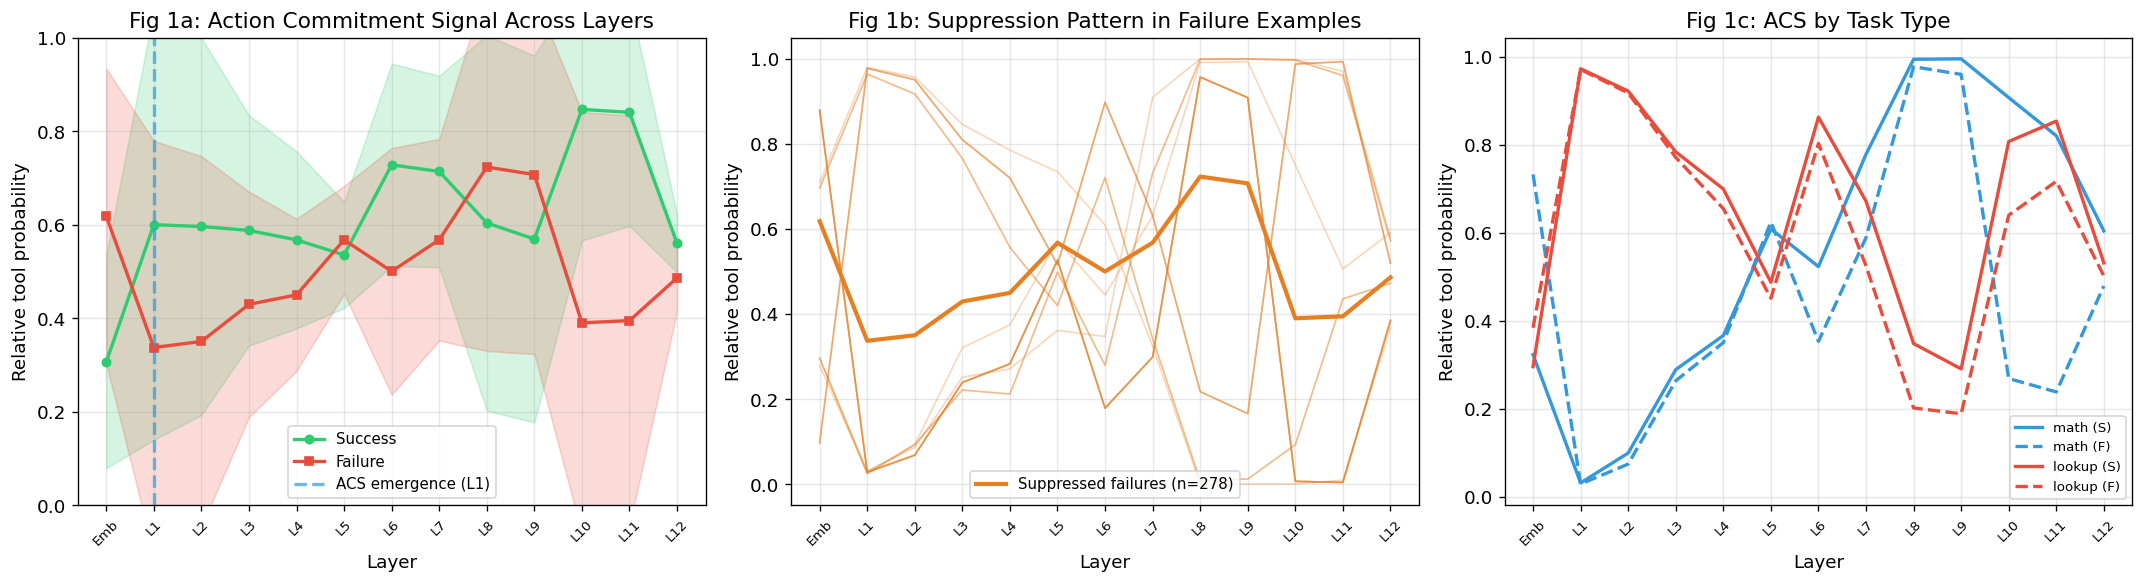

  Saved: fig1_acs_curves.png


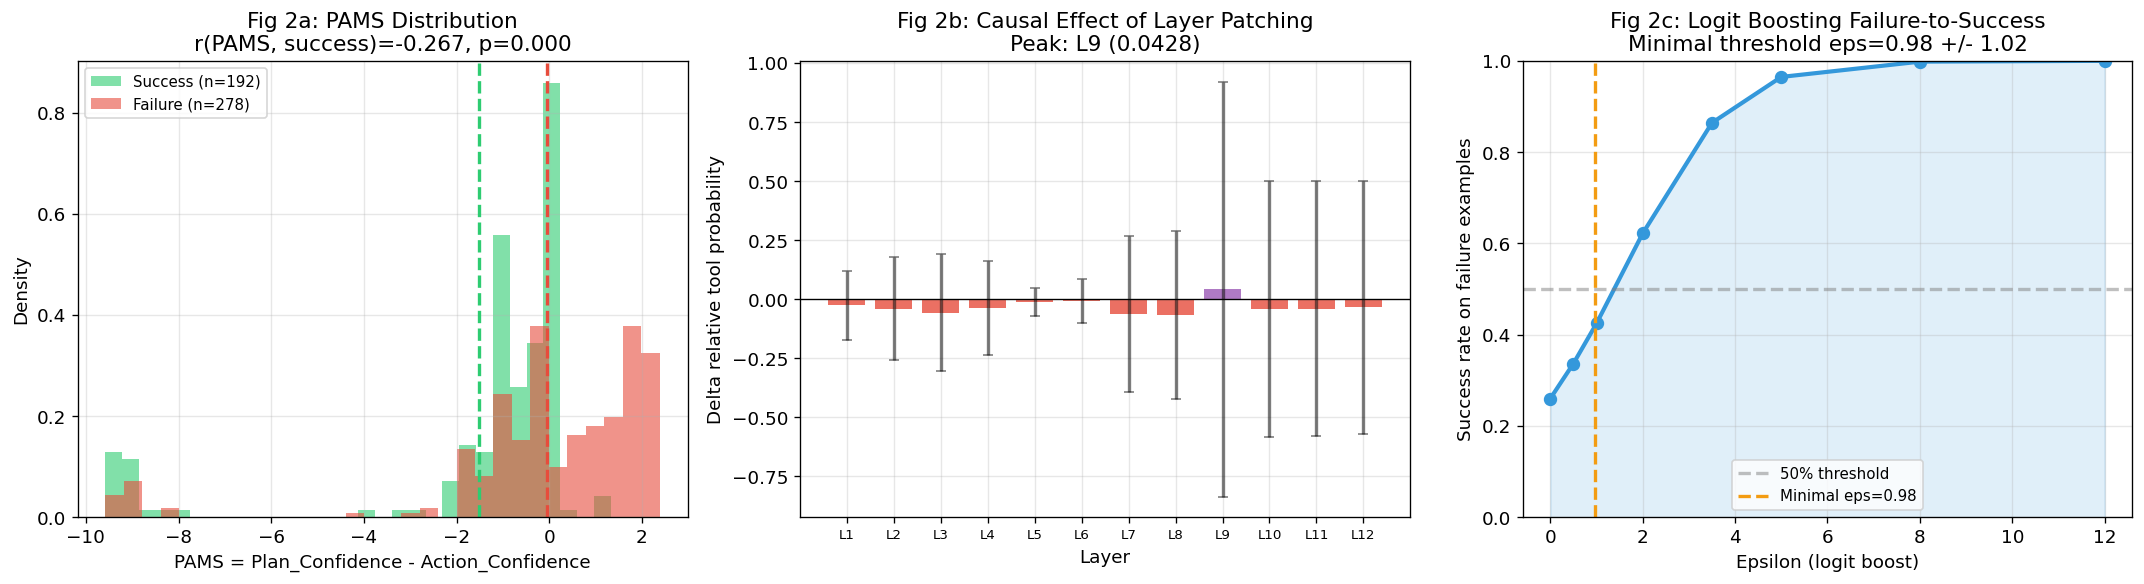

  Saved: fig2_pams_patching_boosting.png


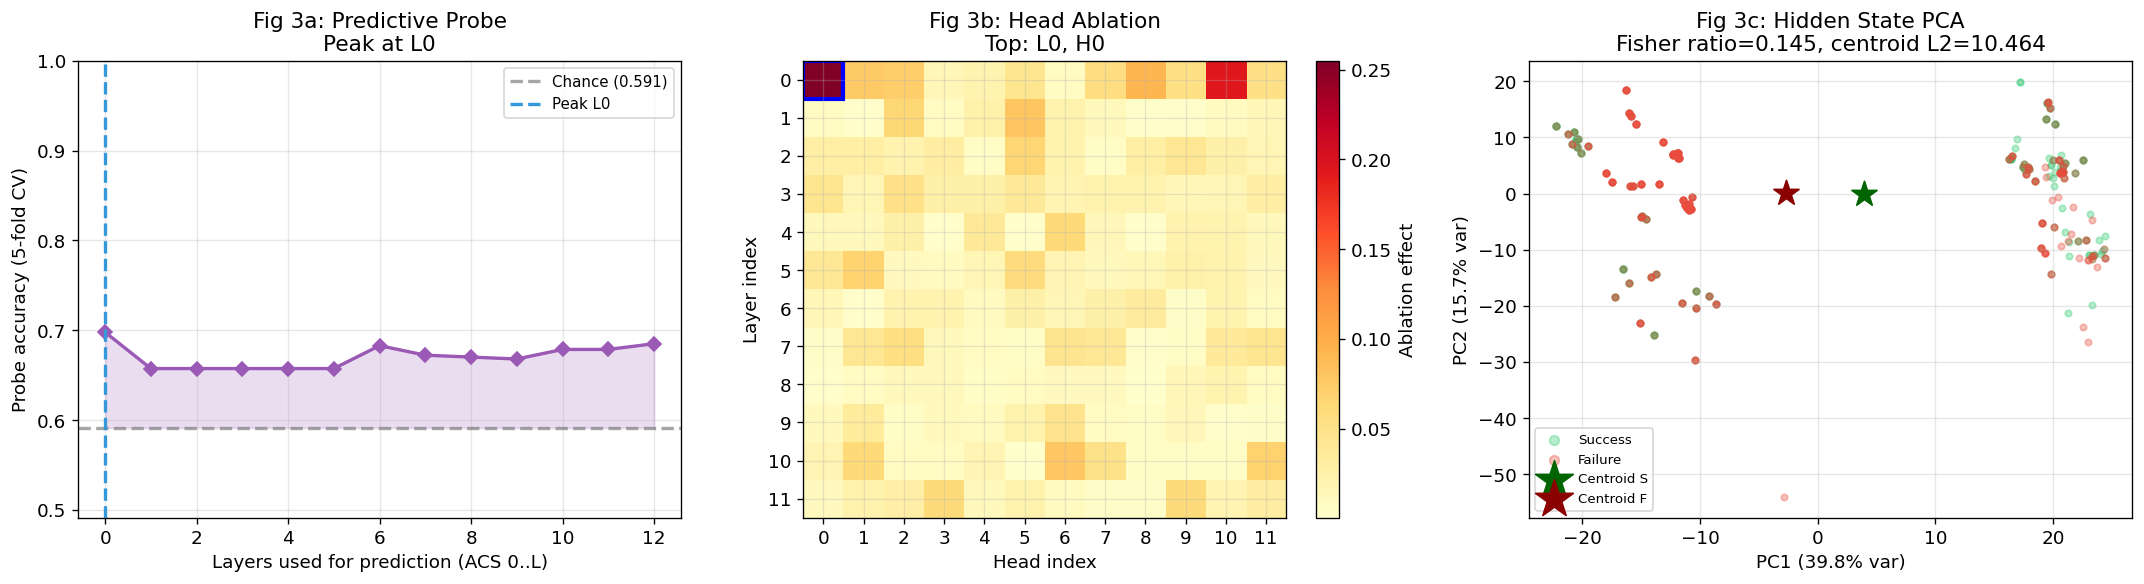

  Saved: fig3_probe_ablation_pca.png


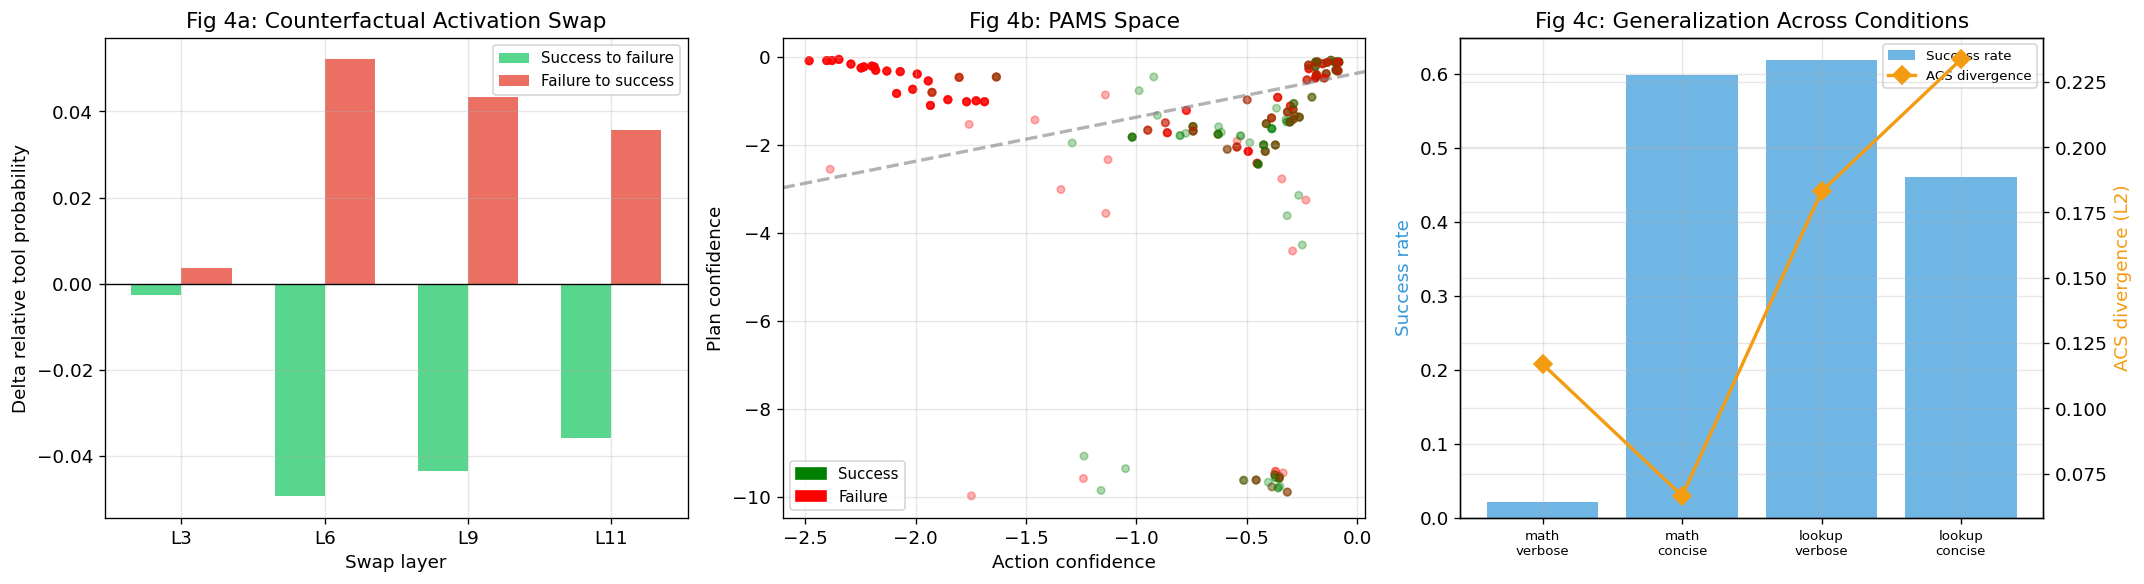

  Saved: fig4_cf_swap_pams_generalization.png


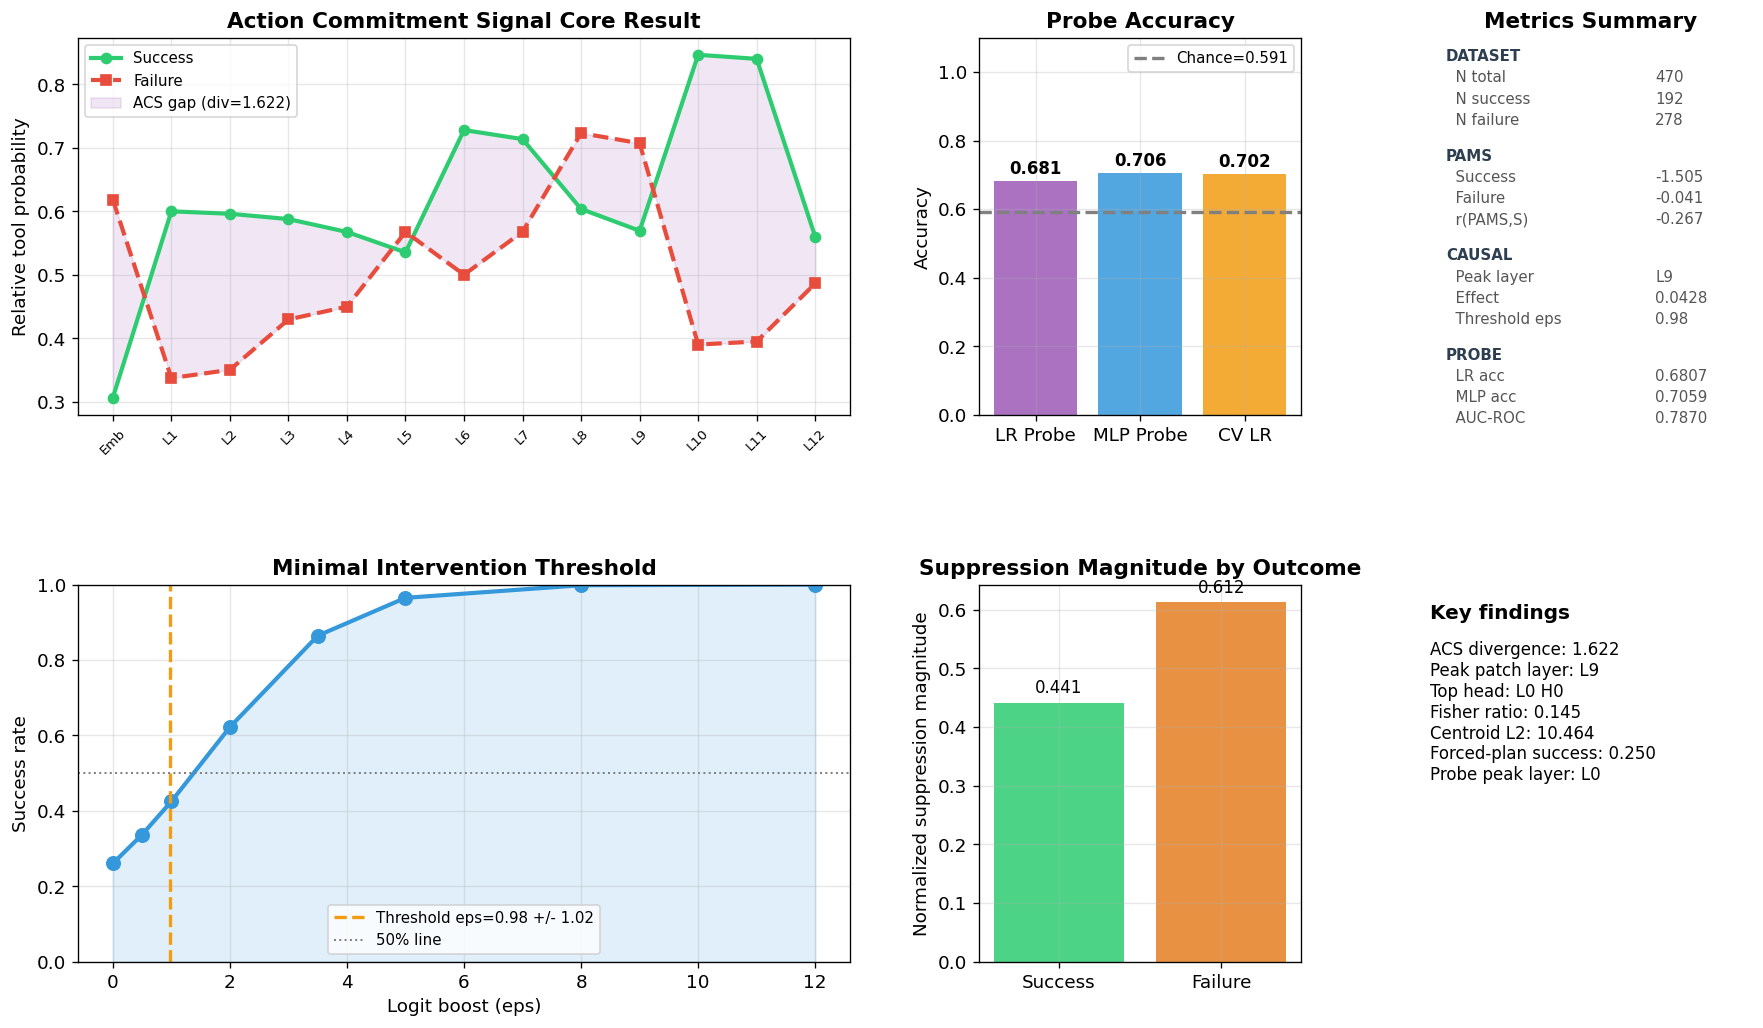

  Saved: fig5_summary_dashboard.png

Section 10 complete.



In [29]:
# SECTION 10: COMPREHENSIVE VISUALIZATION
# ============================================================================

print("="*65)
print("SECTION 10: VISUALIZATION")
print("="*65)

# Local helper only for this section: suppression = peak ACS followed by later drop.
def _viz_suppression_stats(acs_curve: np.ndarray, peak_window: Tuple[int, int] = (2, 8)) -> Dict[str, float]:
    smoothed = np.convolve(acs_curve, np.ones(3) / 3, mode="same")
    lo, hi = peak_window
    peak_idx = int(np.argmax(smoothed[lo:hi])) + lo
    peak_val = float(smoothed[peak_idx])
    final_val = float(smoothed[-1])
    drop = max(peak_val - final_val, 0.0)
    return {
        "peak_idx": peak_idx,
        "peak_val": peak_val,
        "final_val": final_val,
        "drop": drop,
        "is_suppressed": bool(drop > 0.05 * max(peak_val, 1e-10)),
    }

plot_peak_causal_layer_idx = globals().get("peak_causal_layer", int(metrics.get("peak_causal_layer", 1)) - 1)
plot_probe_peak_layer = int(metrics.get("probe_peak_layer", np.argmax(layer_probe_accs)))
plot_top_layer = globals().get("top_layer", int(metrics.get("top_ablation_layer", 0)))
plot_top_head = globals().get("top_head", int(metrics.get("top_ablation_head", 0)))
plot_centroid_l2 = float(globals().get("centroid_l2", np.linalg.norm(hidden_all[labels_all == 1].mean(axis=0) - hidden_all[labels_all == 0].mean(axis=0))))
chance_level = float(max(np.mean(labels_all), 1 - np.mean(labels_all)))

# Figure 1: ACS across layers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(N_LAYERS + 1)
ax.plot(x, acs_mean_success, color=COLORS['success'], label='Success', marker='o', ms=5)
ax.fill_between(x, acs_mean_success - acs_std_success, acs_mean_success + acs_std_success,
                alpha=0.2, color=COLORS['success'])
ax.plot(x, acs_mean_failure, color=COLORS['failure'], label='Failure', marker='s', ms=5)
ax.fill_between(x, acs_mean_failure - acs_std_failure, acs_mean_failure + acs_std_failure,
                alpha=0.2, color=COLORS['failure'])
ax.axvline(x=emergence_layer, color=COLORS['acs'], linestyle='--', alpha=0.7,
           label=f'ACS emergence (L{emergence_layer})')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels, rotation=45, fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Relative tool probability")
ax.set_title("Fig 1a: Action Commitment Signal Across Layers")
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

ax = axes[1]
supp_curves = [e.acs_curve for e in all_examples if not e.success and _viz_suppression_stats(e.acs_curve)["is_suppressed"]]
nosupp_curves = [e.acs_curve for e in all_examples if not e.success and not _viz_suppression_stats(e.acs_curve)["is_suppressed"]]
for curve in supp_curves[:min(15, len(supp_curves))]:
    ax.plot(x, curve, color=COLORS['suppressed'], alpha=0.3, linewidth=1)
for curve in nosupp_curves[:min(15, len(nosupp_curves))]:
    ax.plot(x, curve, color=COLORS['failure'], alpha=0.2, linewidth=1)
if supp_curves:
    ax.plot(x, np.mean(supp_curves, axis=0), color=COLORS['suppressed'], linewidth=2.5,
            label=f'Suppressed failures (n={len(supp_curves)})')
if nosupp_curves:
    ax.plot(x, np.mean(nosupp_curves, axis=0), color=COLORS['failure'], linewidth=2.5,
            label=f'Non-suppressed failures (n={len(nosupp_curves)})')
ax.set_xticks(x)
ax.set_xticklabels(layer_labels, rotation=45, fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Relative tool probability")
ax.set_title("Fig 1b: Suppression Pattern in Failure Examples")
ax.legend(fontsize=9)

ax = axes[2]
for task, clr in [("math", "#3498db"), ("lookup", "#e74c3c")]:
    for success, ls in [(True, '-'), (False, '--')]:
        exs = [e for e in all_examples if e.task_type == task and e.success == success]
        if not exs:
            continue
        mean_c = np.mean([e.acs_curve for e in exs], axis=0)
        ax.plot(x, mean_c, color=clr, linestyle=ls, linewidth=2,
                label=f"{task} ({'S' if success else 'F'})")
ax.set_xticks(x)
ax.set_xticklabels(layer_labels, rotation=45, fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Relative tool probability")
ax.set_title("Fig 1c: ACS by Task Type")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_acs_curves.png"), bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: fig1_acs_curves.png")

# Figure 2: PAMS distribution and causal patching
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(pams_arr[labels_all == 1], bins=30, color=COLORS['success'], alpha=0.6, density=True,
        label=f'Success (n={sum(labels_all)})')
ax.hist(pams_arr[labels_all == 0], bins=30, color=COLORS['failure'], alpha=0.6, density=True,
        label=f'Failure (n={sum(1 - labels_all)})')
ax.axvline(pams_success_mean, color=COLORS['success'], linestyle='--', linewidth=2)
ax.axvline(pams_failure_mean, color=COLORS['failure'], linestyle='--', linewidth=2)
ax.set_xlabel("PAMS = Plan_Confidence - Action_Confidence")
ax.set_ylabel("Density")
ax.set_title(f"Fig 2a: PAMS Distribution\nr(PAMS, success)={r_pams_success:.3f}, p={p_pams:.3f}")
ax.legend(fontsize=9)

ax = axes[1]
layer_x = np.arange(1, N_LAYERS + 1)
colors_effect = [COLORS['causal'] if v > 0 else COLORS['failure'] for v in mean_causal_effect]
std_causal_effect_plot = (
    np.std(np.array(all_causal_effects), axis=0)
    if 'all_causal_effects' in globals() and len(all_causal_effects) > 0
    else np.zeros_like(mean_causal_effect)
)
ax.bar(layer_x, mean_causal_effect, color=colors_effect, alpha=0.8,
       yerr=std_causal_effect_plot, capsize=3, error_kw={'alpha': 0.5})
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Delta relative tool probability")
ax.set_title(f"Fig 2b: Causal Effect of Layer Patching\nPeak: L{plot_peak_causal_layer_idx+1} ({mean_causal_effect[plot_peak_causal_layer_idx]:.4f})")
ax.set_xticks(layer_x)
ax.set_xticklabels([f"L{i}" for i in layer_x], fontsize=8)

ax = axes[2]
eps_vals = list(boost_mean.keys())
succ_vals = list(boost_mean.values())
ax.plot(eps_vals, succ_vals, color=COLORS['acs'], marker='o', ms=7, linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(mean_threshold, color=COLORS['pams'], linestyle='--', linewidth=2,
           label=f'Minimal eps={mean_threshold:.2f}')
ax.fill_between(eps_vals, succ_vals, alpha=0.15, color=COLORS['acs'])
ax.set_xlabel("Epsilon (logit boost)")
ax.set_ylabel("Success rate on failure examples")
ax.set_title(f"Fig 2c: Logit Boosting Failure-to-Success\nMinimal threshold eps={mean_threshold:.2f} +/- {std_threshold:.2f}")
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_pams_patching_boosting.png"), bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: fig2_pams_patching_boosting.png")

# Figure 3: Probe accuracy, head ablation, and PCA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
layer_x2 = np.arange(len(layer_probe_accs))
ax.plot(layer_x2, layer_probe_accs, color=COLORS['causal'], marker='D', ms=6, linewidth=2)
ax.axhline(chance_level, color='gray', linestyle='--', alpha=0.7, label=f'Chance ({chance_level:.3f})')
ax.axvline(plot_probe_peak_layer, color=COLORS['acs'], linestyle='--', linewidth=2,
           label=f'Peak L{plot_probe_peak_layer}')
ax.fill_between(layer_x2, chance_level, layer_probe_accs,
                where=[acc > chance_level for acc in layer_probe_accs],
                alpha=0.2, color=COLORS['causal'])
ax.set_xlabel("Layers used for prediction (ACS 0..L)")
ax.set_ylabel("Probe accuracy (5-fold CV)")
ax.set_title(f"Fig 3a: Predictive Probe\nPeak at L{plot_probe_peak_layer}")
ax.legend(fontsize=9)
ax.set_ylim(max(0, chance_level - 0.1), 1.0)

ax = axes[1]
im = ax.imshow(ablation_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xlabel("Head index")
ax.set_ylabel("Layer index")
ax.set_title(f"Fig 3b: Head Ablation\nTop: L{plot_top_layer}, H{plot_top_head}")
plt.colorbar(im, ax=ax, label='Ablation effect')
ax.set_xticks(range(N_HEADS))
ax.set_yticks(range(N_LAYERS))
ax.add_patch(plt.Rectangle((plot_top_head - 0.5, plot_top_layer - 0.5), 1, 1,
                           fill=False, edgecolor='blue', lw=2.5))

ax = axes[2]
pca2d = PCA(n_components=2, random_state=SEED)
X_2d = pca2d.fit_transform(X_scaled)
ax.scatter(X_2d[labels_all == 1, 0], X_2d[labels_all == 1, 1],
           c=COLORS['success'], alpha=0.35, s=15, label='Success')
ax.scatter(X_2d[labels_all == 0, 0], X_2d[labels_all == 0, 1],
           c=COLORS['failure'], alpha=0.35, s=15, label='Failure')
centroid_success_plot = hidden_all[labels_all == 1].mean(axis=0)
centroid_failure_plot = hidden_all[labels_all == 0].mean(axis=0)
c_s2d = pca2d.transform(scaler.transform(centroid_success_plot.reshape(1, -1)))
c_f2d = pca2d.transform(scaler.transform(centroid_failure_plot.reshape(1, -1)))
ax.scatter(*c_s2d.T, color='darkgreen', marker='*', s=250, zorder=5, label='Centroid S')
ax.scatter(*c_f2d.T, color='darkred', marker='*', s=250, zorder=5, label='Centroid F')
ax.set_xlabel(f"PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"Fig 3c: Hidden State PCA\nFisher ratio={fisher:.3f}, centroid L2={plot_centroid_l2:.3f}")
ax.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_probe_ablation_pca.png"), bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: fig3_probe_ablation_pca.png")

# Figure 4: Counterfactual swap, PAMS, and generalization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x_cf = np.arange(len(swap_layers))
width = 0.35
ax.bar(x_cf - width/2, cf_results["s2f_deltas"], width,
       color=COLORS['success'], alpha=0.8, label='Success to failure')
ax.bar(x_cf + width/2, cf_results["f2s_deltas"], width,
       color=COLORS['failure'], alpha=0.8, label='Failure to success')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_cf)
ax.set_xticklabels([f"L{l}" for l in swap_layers])
ax.set_xlabel("Swap layer")
ax.set_ylabel("Delta relative tool probability")
ax.set_title("Fig 4a: Counterfactual Activation Swap")
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(act_arr, plan_arr, c=['green' if l else 'red' for l in labels_all], alpha=0.3, s=20)
ax.set_xlabel("Action confidence")
ax.set_ylabel("Plan confidence")
ax.set_title("Fig 4b: PAMS Space")
ax.axline((np.median(act_arr), np.median(plan_arr)), slope=1, color='gray', linestyle='--', alpha=0.6)
handles = [mpatches.Patch(color='green', label='Success'),
           mpatches.Patch(color='red', label='Failure')]
ax.legend(handles=handles, fontsize=9)

ax = axes[2]
if 'gen_results' in globals() and gen_results:
    keys = list(gen_results.keys())
    sr_vals = [gen_results[k]["success_rate"] for k in keys]
    div_vals = [gen_results[k]["acs_div"] for k in keys]
    x_gen = np.arange(len(keys))
    ax2_twin = ax.twinx()
    ax.bar(x_gen, sr_vals, color=COLORS['acs'], alpha=0.7, label='Success rate')
    ax2_twin.plot(x_gen, div_vals, color=COLORS['pams'], marker='D', ms=8, linewidth=2, label='ACS divergence')
    ax.set_xticks(x_gen)
    ax.set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=8)
    ax.set_ylabel("Success rate", color=COLORS['acs'])
    ax2_twin.set_ylabel("ACS divergence (L2)", color=COLORS['pams'])
    ax.set_title("Fig 4c: Generalization Across Conditions")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
else:
    ax.axis('off')
    ax.text(0.5, 0.5, "Generalization results not available", ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_cf_swap_pams_generalization.png"),
            bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: fig4_cf_swap_pams_generalization.png")

# Figure 5: Summary dashboard
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

ax = fig.add_subplot(gs[0, :2])
ax.plot(np.arange(13), acs_mean_success, 'o-', color=COLORS['success'], label='Success', lw=2.5)
ax.plot(np.arange(13), acs_mean_failure, 's--', color=COLORS['failure'], label='Failure', lw=2.5)
ax.fill_between(np.arange(13), acs_mean_failure, acs_mean_success,
                alpha=0.15, color=COLORS['causal'], label=f'ACS gap (div={act_divergence:.3f})')
ax.set_xticks(np.arange(13))
ax.set_xticklabels(layer_labels, rotation=45, fontsize=8)
ax.set_title("Action Commitment Signal Core Result", fontweight='bold')
ax.set_ylabel("Relative tool probability")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[0, 2])
methods = ['LR Probe', 'MLP Probe', 'CV LR']
accs = [acc_lr, acc_mlp, cv_scores.mean()]
colors = [COLORS['causal'], COLORS['acs'], COLORS['pams']]
bars = ax.bar(methods, accs, color=colors, alpha=0.85)
ax.axhline(chance_level, color='gray', linestyle='--', label=f'Chance={chance_level:.3f}')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title("Probe Accuracy", fontweight='bold')
ax.set_ylabel("Accuracy")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[0, 3])
ax.axis('off')
summary_lines = [
    ("DATASET", ""),
    ("  N total", f"{metrics['n_total']}"),
    ("  N success", f"{metrics['n_success']}"),
    ("  N failure", f"{metrics['n_failure']}"),
    ("", ""),
    ("PAMS", ""),
    ("  Success", f"{metrics['pams_success_mean']:.3f}"),
    ("  Failure", f"{metrics['pams_failure_mean']:.3f}"),
    ("  r(PAMS,S)", f"{metrics['r_pams_success']:.3f}"),
    ("", ""),
    ("CAUSAL", ""),
    ("  Peak layer", f"L{metrics['peak_causal_layer']}"),
    ("  Effect", f"{metrics['mean_causal_effect']:.4f}"),
    ("  Threshold eps", f"{metrics['threshold_mean']:.2f}"),
    ("", ""),
    ("PROBE", ""),
    ("  LR acc", f"{metrics['probe_lr_accuracy']:.4f}"),
    ("  MLP acc", f"{metrics['probe_mlp_accuracy']:.4f}"),
    ("  AUC-ROC", f"{metrics['probe_lr_auc']:.4f}"),
]
y_pos = 0.97
for key, val in summary_lines:
    if key == "" and val == "":
        y_pos -= 0.04
        continue
    weight = 'bold' if not key.startswith(' ') else 'normal'
    color = '#2c3e50' if not key.startswith(' ') else '#555'
    ax.text(0.05, y_pos, key, transform=ax.transAxes,
            fontsize=9, fontweight=weight, color=color, va='top')
    if val:
        ax.text(0.7, y_pos, val, transform=ax.transAxes,
                fontsize=9, color=color, va='top')
    y_pos -= 0.056
ax.set_title("Metrics Summary", fontweight='bold')

ax = fig.add_subplot(gs[1, :2])
ax.plot(eps_vals, succ_vals, 'o-', color=COLORS['acs'], lw=2.5, ms=8)
ax.fill_between(eps_vals, succ_vals, alpha=0.15, color=COLORS['acs'])
ax.axvline(mean_threshold, color=COLORS['pams'], linestyle='--', lw=2,
           label=f'Threshold eps={mean_threshold:.2f} +/- {std_threshold:.2f}')
ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='50% line')
ax.set_xlabel("Logit boost (eps)")
ax.set_ylabel("Success rate")
ax.set_title("Minimal Intervention Threshold", fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

ax = fig.add_subplot(gs[1, 2])
sup_rates = [metrics['suppression_success_mean'], metrics['suppression_failure_mean']]
labels_sr = ['Success', 'Failure']
ax.bar(labels_sr, sup_rates, color=[COLORS['success'], COLORS['suppressed']], alpha=0.85)
ax.set_ylabel("Normalized suppression magnitude")
ax.set_title("Suppression Magnitude by Outcome", fontweight='bold')
for i, val in enumerate(sup_rates):
    ax.text(i, val + 0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=10)

ax = fig.add_subplot(gs[1, 3])
ax.axis('off')
ax.text(0.0, 0.95, "Key findings", fontsize=12, fontweight='bold', va='top')
key_text = (
    f"ACS divergence: {act_divergence:.3f}\n"
    f"Peak patch layer: L{plot_peak_causal_layer_idx+1}\n"
    f"Top head: L{plot_top_layer} H{plot_top_head}\n"
    f"Fisher ratio: {fisher:.3f}\n"
    f"Centroid L2: {plot_centroid_l2:.3f}\n"
    f"Forced-plan success: {forced_success_rate:.3f}\n"
    f"Probe peak layer: L{plot_probe_peak_layer}"
)
ax.text(0.0, 0.85, key_text, fontsize=10, va='top')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_summary_dashboard.png"), bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: fig5_summary_dashboard.png")

print("\nSection 10 complete.\n")

# ============================================================================


## 11: STRUCTURED RESULTS & CONCLUSIONS


In [30]:
# SECTION 11: STRUCTURED RESULTS & CONCLUSIONS
# ============================================================================

print("="*65)
print("SECTION 11: STRUCTURED RESULTS AND CONCLUSIONS")
print("="*65)

print(f"""
1. Behavioral misalignment is clear in confidence and decision space.
   - The mean plan-action gap is {metrics['plan_action_gap']:.3f}.
   - PAMS is higher in failures than in successes ({pams_failure_mean:.3f} vs {pams_success_mean:.3f}).
   - PAMS is negatively correlated with success (r={r_pams_success:.3f}, p={p_pams:.4f}).
   - Forcing the correct plan into failing examples yields only {forced_success_rate:.3f} success, so correct planning alone usually does not rescue execution.

2. A hidden-state ACS is detectable and behaviorally relevant.
   - The best ACS probe layer is L{best_acs_layer}.
   - ACS probe AUC / AP / Acc / Brier = {acs_auc_best:.4f} / {acs_ap_best:.4f} / {acs_acc_best:.4f} / {acs_brier_best:.4f}.
   - ACS separability is strong (Cohen's d = {acs_score_d:.4f}).
   - ACS threshold classification accuracy is {acs_theta_success_rate:.4f}.
   - Activation patching peaks at L{peak_causal_layer+1} with effect {peak_effect:.4f}.

3. Failures reflect both weaker commitment and downstream suppression.
   - Final-layer ACS is lower in failures than successes ({acs_mean_failure[-1]:.4f} vs {acs_mean_success[-1]:.4f}).
   - Suppression is stronger in failures than successes ({metrics['suppression_failure_mean']:.4f} vs {metrics['suppression_success_mean']:.4f}).
   - Early/Late ACS ratios differ by outcome (success={np.mean(elr_success):.3f}, failure={np.mean(elr_failure):.3f}).
   - Circuit-level evidence is consistent with this pattern: the dominant ablation layer is L{metrics['decisive_ablation_layer']} and the top suppressive head is L{metrics['top_suppressive_head_layer']} H{metrics['top_suppressive_head']}.

4. Failure is predictable before completion.
   - Logistic probe performance is accuracy={acc_lr:.4f}, AUC={auc_lr:.4f}, AP={prec_lr:.4f}.
   - MLP probe performance is accuracy={acc_mlp:.4f}, AUC={auc_mlp:.4f}, AP={prec_mlp:.4f}.
   - The predictive signal is present from early layers and remains stable across depth.
   - Peak ACS predictive layer is L{metrics['probe_peak_layer']}.

5. The mechanism is context-dependent rather than fully invariant.
   - ACS is strongly separated from task and style subspaces (angles {subspace_angle_task:.2f} deg and {subspace_angle_style:.2f} deg).
   - Cross-condition transfer is asymmetric across task and style splits.
   - The results support a task-sensitive decision mechanism rather than a representation that generalizes uniformly across conditions.
""")

print("Section 11 complete.")

# ============================================================================


SECTION 11: STRUCTURED RESULTS AND CONCLUSIONS

1. Behavioral misalignment is clear in confidence and decision space.
   - The mean plan-action gap is 1.464.
   - PAMS is higher in failures than in successes (-0.041 vs -1.505).
   - PAMS is negatively correlated with success (r=-0.267, p=0.0000).
   - Forcing the correct plan into failing examples yields only 0.250 success, so correct planning alone usually does not rescue execution.

2. A hidden-state ACS is detectable and behaviorally relevant.
   - The best ACS probe layer is L9.
   - ACS probe AUC / AP / Acc / Brier = 0.7872 / 0.5754 / 0.6807 / 0.2056.
   - ACS separability is strong (Cohen's d = 1.5288).
   - ACS threshold classification accuracy is 0.7213.
   - Activation patching peaks at L9 with effect 0.0428.

3. Failures reflect both weaker commitment and downstream suppression.
   - Final-layer ACS is lower in failures than successes (0.4863 vs 0.5601).
   - Suppression is stronger in failures than successes (0.6123 vs 0.441

## 12: MECHANISTIC SUMMARY


In [31]:
# SECTION 12: MECHANISTIC SUMMARY
# ============================================================================

print("="*65)
print("SECTION 12: MECHANISTIC SUMMARY")
print("="*65)

h1_status = "SUPPORTED" if forced_success_rate < 0.35 and metrics['plan_action_gap'] > 1.0 else "PARTIAL"
h2_status = "SUPPORTED" if acs_auc_best > 0.75 and peak_effect > 0.02 else "SUPPORTED WITH CAVEATS"
h3_status = "SUPPORTED WITH CAVEATS" if (
    metrics.get('suppression_failure_mean', 0.0) > metrics.get('suppression_success_mean', 0.0)
    and metrics.get('suppressive_head_effect', 0.0) > 0
) else "PARTIAL"
h4_status = "SUPPORTED" if acc_lr > 0.65 and auc_lr > 0.75 else "PARTIAL"

print(f"""
H1. Planning and action are mechanistically separable: {h1_status}
  Evidence: the plan-action gap is {metrics['plan_action_gap']:.3f}, PAMS is strongly separated by outcome, and forcing the correct plan into failing examples raises success only to {forced_success_rate:.3f}. This supports a disconnect between planning quality and action execution.

H2. A hidden-state ACS exists and is behaviorally relevant: {h2_status}
  Evidence: the best ACS probe appears at L{best_acs_layer} with AUC {acs_auc_best:.4f}, effect size {acs_score_d:.4f}, threshold accuracy {acs_theta_success_rate:.4f}, and a patching peak at L{peak_causal_layer+1} with effect {peak_effect:.4f}.

H3. Failure reflects both weaker commitment and downstream suppression: {h3_status}
  Evidence: failures end with lower ACS than successes, show higher suppression ({metrics['suppression_failure_mean']:.4f} vs {metrics['suppression_success_mean']:.4f}), and remain consistent with circuit-level evidence from ablation and suppressive-head analysis.

H4. Failure is predictable from internal activations before completion: {h4_status}
  Evidence: logistic probe performance is {acc_lr:.4f}/{auc_lr:.4f}/{prec_lr:.4f} for accuracy/AUC/AP, MLP performance is {acc_mlp:.4f}/{auc_mlp:.4f}/{prec_mlp:.4f}, and the predictive signal is available from early layers and remains stable across depth.
""")

print("Summary")
print("-"*65)
print(f"""
The notebook supports a conservative mechanistic account of planning-action disconnect. Failures are associated with a measurable gap between planning confidence and action commitment, a decodable ACS centered at L{best_acs_layer}, and intervention-sensitive circuitry. The strongest evidence supports behavioral misalignment, ACS detectability, and early predictability. The weaker part of the story is generalization: transfer across conditions is asymmetric, so the current results support a context-dependent, task-sensitive decision mechanism that is not fully invariant across conditions.
""")

print("Section 12 complete.")

# ============================================================================


SECTION 12: MECHANISTIC SUMMARY

H1. Planning and action are mechanistically separable: SUPPORTED
  Evidence: the plan-action gap is 1.464, PAMS is strongly separated by outcome, and forcing the correct plan into failing examples raises success only to 0.250. This supports a disconnect between planning quality and action execution.

H2. A hidden-state ACS exists and is behaviorally relevant: SUPPORTED
  Evidence: the best ACS probe appears at L9 with AUC 0.7872, effect size 1.5288, threshold accuracy 0.7213, and a patching peak at L9 with effect 0.0428.

H3. Failure reflects both weaker commitment and downstream suppression: SUPPORTED WITH CAVEATS
  Evidence: failures end with lower ACS than successes, show higher suppression (0.6123 vs 0.4410), and remain consistent with circuit-level evidence from ablation and suppressive-head analysis.

H4. Failure is predictable from internal activations before completion: SUPPORTED
  Evidence: logistic probe performance is 0.6807/0.7870/0.5664 for